# ALBEF aplicado a textiles andinos: línea base contrastiva con OpenCLIP

**Curso:** MCC225A – IA Generativa y Aprendizaje Multimodal  
**Estudiante:** Henry Sánchez Alvarado  
**Modelo asignado:** ALBEF: Align Before Fuse  
**Cuadernos relacionados:** C5, C6 y C10  

Este notebook implementa una línea base reproducible de recuperación imagen–texto usando OpenCLIP.  
El objetivo no es implementar ALBEF completo, sino reproducir la etapa de alineamiento contrastivo imagen–texto, equivalente al componente ITC de ALBEF, y justificar la mejora futura hacia fusión profunda y re-ranking.

#Importaciones, semilla y entorno

## Alcance del experimento

Este notebook trabaja con un conjunto pequeño y controlado de imágenes de prueba inspiradas en textiles andinos y textos candidatos asociados.

El flujo experimental es:

1. Cargar imágenes y textos candidatos.
2. Usar OpenCLIP para extraer embeddings de imagen y texto.
3. Normalizar embeddings.
4. Calcular similitud coseno.
5. Generar rankings imagen → texto y texto → imagen.
6. Calcular métricas Recall@K.
7. Analizar errores y hard negatives.
8. Relacionar los resultados con ALBEF y los cuadernos C5, C6 y C10.

No se entrena un modelo desde cero.  
No se implementa la fusión profunda completa de ALBEF.  
La fusión crossmodal se plantea como mejora futura mediante re-ranking.

## Resultado principal esperado

El resultado principal del notebook es una evaluación de retrieval multimodal usando OpenCLIP:

- Imagen → texto: ranking de descripciones candidatas para cada imagen.
- Texto → imagen: ranking de imágenes candidatas para cada descripción.
- Métricas: Recall@1, Recall@3 y Recall@5.
- Evidencias: matriz de similitud, rankings Top-K, heatmap y análisis de errores.

Este resultado permite defender técnicamente la etapa de alineamiento previa a la fusión, que es la idea central de ALBEF.

## Índice

1. Verificación del entorno y dependencias  
2. Configuración de rutas del repositorio  
3. Carga de textos candidatos  
4. Carga o generación de imágenes de prueba  
5. Carga del modelo OpenCLIP  
6. Extracción de embeddings  
7. Cálculo de similitud coseno  
8. Retrieval imagen → texto  
9. Retrieval texto → imagen  
10. Métricas Recall@K  
11. Análisis de errores y hard negatives  
12. Relación con ALBEF: ITC, ITM y re-ranking  
13. Relación con C5, C6 y C10  
14. Limitaciones y mejoras futuras  
15. Exportación de resultados

In [83]:
# ============================================================
# Verificación del entorno del proyecto
# ============================================================

import sys
import platform
from pathlib import Path

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Sistema:", platform.platform())
print("Directorio actual:", Path.cwd())

Python executable: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\.venv\Scripts\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Sistema: Windows-10-10.0.19045-SP0
Directorio actual: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\notebooks


In [84]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from sklearn.metrics.pairwise import cosine_similarity

import torch
import open_clip

# -------------------------------
# Reproducibilidad
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dispositivo detectado: {DEVICE}")
print(f"Semilla fijada en: {SEED}")
print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("OpenCLIP importado correctamente")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Dispositivo detectado: cpu
Semilla fijada en: 42
Torch: 2.12.0+cpu
CUDA disponible: False
OpenCLIP importado correctamente
Pandas: 3.0.3
NumPy: 2.4.6


#Estructura de carpetas

In [85]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"
TEXTS_DIR = DATA_DIR / "texts"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

CANDIDATE_TEXTS_PATH = TEXTS_DIR / "candidate_texts.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
TEXTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("IMAGES_DIR:", IMAGES_DIR)
print("TEXTS_DIR:", TEXTS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("CANDIDATE_TEXTS_PATH:", CANDIDATE_TEXTS_PATH)
print("Existe candidate_texts.csv:", CANDIDATE_TEXTS_PATH.exists())

PROJECT_ROOT: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos
DATA_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data
IMAGES_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\images
TEXTS_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\texts
RESULTS_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results
FIGURES_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\figures
CANDIDATE_TEXTS_PATH: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\texts\candidate_texts.csv
Existe candidate_texts.csv: True


# 3. Carga de textos candidatos

In [86]:
# ============================================================
# ============================================================

texts_df = pd.read_csv(CANDIDATE_TEXTS_PATH)

print("Número total de textos candidatos:", len(texts_df))
display(texts_df)

Número total de textos candidatos: 15


,id,texto,tipo,imagen_correcta
0,TXT_01,Textil andino sintético con franjas horizontal...,correcto,T01
1,TXT_02,Textil andino sintético con franjas verticales...,correcto,T02
2,TXT_03,Textil andino sintético con motivo geométrico ...,correcto,T03
3,TXT_04,Textil andino sintético con rombos centrales r...,correcto,T04
4,TXT_05,Textil andino sintético con composición modula...,correcto,T05
5,TXT_06,Textil andino sintético con bandas decorativas...,correcto,T06
6,TXT_07,Textil andino sintético con bloques cuadrados ...,correcto,T07
7,TXT_08,Textil andino sintético con composición bilate...,correcto,T08
8,TXT_09,Textil andino sintético de alta densidad geomé...,correcto,T09
9,TXT_10,Textil andino sintético con motivo geométrico ...,correcto,T10


In [87]:
# ============================================================
# Lista de textos para codificación con OpenCLIP
# ============================================================

candidate_texts = texts_df["texto"].tolist()
text_ids = texts_df["id"].tolist()

print("Cantidad de textos enviados al modelo:", len(candidate_texts))
print("Primer texto candidato:")
print(candidate_texts[0])

Cantidad de textos enviados al modelo: 15
Primer texto candidato:
Textil andino sintético con franjas horizontales repetidas y organización simétrica del color.


In [88]:
# ============================================================
# Diccionario de correspondencias correctas
# ============================================================

correct_texts_df = texts_df[texts_df["tipo"] == "correcto"].copy()

text_to_image_gt = dict(
    zip(correct_texts_df["id"], correct_texts_df["imagen_correcta"])
)

image_to_text_gt = {
    image_id: text_id
    for text_id, image_id in text_to_image_gt.items()
}

print("Correspondencia texto → imagen:")
display(pd.DataFrame([
    {"texto_id": text_id, "imagen_correcta": image_id}
    for text_id, image_id in text_to_image_gt.items()
]))

print("Correspondencia imagen → texto:")
display(pd.DataFrame([
    {"imagen_id": image_id, "texto_correcto": text_id}
    for image_id, text_id in image_to_text_gt.items()
]))

Correspondencia texto → imagen:


,texto_id,imagen_correcta
0,TXT_01,T01
1,TXT_02,T02
2,TXT_03,T03
3,TXT_04,T04
4,TXT_05,T05
5,TXT_06,T06
6,TXT_07,T07
7,TXT_08,T08
8,TXT_09,T09
9,TXT_10,T10


Correspondencia imagen → texto:


,imagen_id,texto_correcto
0,T01,TXT_01
1,T02,TXT_02
2,T03,TXT_03
3,T04,TXT_04
4,T05,TXT_05
5,T06,TXT_06
6,T07,TXT_07
7,T08,TXT_08
8,T09,TXT_09
9,T10,TXT_10


### Interpretación

Los 15 textos candidatos permiten simular un escenario de recuperación multimodal.  
Los textos correctos describen patrones esperados en las imágenes de prueba.  
Los distractores representan descripciones visualmente posibles, pero incorrectas para el conjunto de imágenes.

Esto permite observar si OpenCLIP recupera el texto correcto en el Top-K o si confunde la imagen con descripciones cercanas, lo que ayuda a identificar hard negatives.

# 4. Diseño experimental y paleta cromática

In [89]:
# ============================================================
# Paleta cromática
# Base: inspirada en fibras naturales de llama, alpaca y vicuña
# Acentos: sutiles y de uso moderado
# ============================================================

PALETTE = {
    "C1": (242, 236, 226),  # blanco hueso
    "C2": (222, 204, 176),  # beige arena
    "C3": (191, 156, 106),  # ocre suave
    "C4": (140, 101, 66),   # marrón medio
    "C5": (95, 64, 42),     # marrón oscuro
    "C6": (160, 156, 148),  # gris piedra
    "C7": (92, 92, 88),     # gris carbón
    "C8": (35, 35, 35),     # negro profundo

    # Acentos sutiles
    "A1": (146, 72, 72),    # rojo cochinilla apagado
    "A2": (86, 106, 130),   # azul añil tenue
    "A3": (102, 122, 92),   # verde musgo suave
}

# Especificación resumida del dataset
dataset_specs = [
    {"id": "T01", "nombre": "Franjas horizontales simétricas", "desc": "Textil andino sintético con franjas horizontales repetidas y organización simétrica del color."},
    {"id": "T02", "nombre": "Franjas verticales alternadas", "desc": "Textil andino sintético con franjas verticales alternadas y estructura visual ordenada."},
    {"id": "T03", "nombre": "Motivo escalonado", "desc": "Textil andino sintético con motivo geométrico escalonado repetido en composición regular."},
    {"id": "T04", "nombre": "Rombos centrales", "desc": "Textil andino sintético con rombos centrales repetidos y simetría axial."},
    {"id": "T05", "nombre": "Cuadrícula modular tipo tocapu", "desc": "Textil andino sintético con composición modular en cuadrícula, inspirada en patrones tipo tocapu."},
    {"id": "T06", "nombre": "Bandas con motivos pequeños", "desc": "Textil andino sintético con bandas decorativas y pequeños motivos geométricos repetidos."},
    {"id": "T07", "nombre": "Composición tipo tablero", "desc": "Textil andino sintético con bloques cuadrados alternados en composición regular tipo tablero."},
    {"id": "T08", "nombre": "Simetría bilateral", "desc": "Textil andino sintético con composición bilateral y equilibrio visual entre ambos lados."},
    {"id": "T09", "nombre": "Alta densidad geométrica", "desc": "Textil andino sintético de alta densidad geométrica con repetición de figuras pequeñas."},
    {"id": "T10", "nombre": "Motivo central con marco", "desc": "Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas."},
]

df_specs = pd.DataFrame(dataset_specs)
df_specs

,id,nombre,desc
0,T01,Franjas horizontales simétricas,Textil andino sintético con franjas horizontal...
1,T02,Franjas verticales alternadas,Textil andino sintético con franjas verticales...
2,T03,Motivo escalonado,Textil andino sintético con motivo geométrico ...
3,T04,Rombos centrales,Textil andino sintético con rombos centrales r...
4,T05,Cuadrícula modular tipo tocapu,Textil andino sintético con composición modula...
5,T06,Bandas con motivos pequeños,Textil andino sintético con bandas decorativas...
6,T07,Composición tipo tablero,Textil andino sintético con bloques cuadrados ...
7,T08,Simetría bilateral,Textil andino sintético con composición bilate...
8,T09,Alta densidad geométrica,Textil andino sintético de alta densidad geomé...
9,T10,Motivo central con marco,Textil andino sintético con motivo geométrico ...


#Funciones auxiliares para dibujo

In [90]:
# ============================================================
# Funciones auxiliares de dibujo
# ============================================================

SIZE = 512

def new_canvas(bg="C1"):
    img = Image.new("RGB", (SIZE, SIZE), PALETTE[bg])
    return img, ImageDraw.Draw(img)

def draw_diamond(draw, center, radius, fill, outline=None, width=2):
    cx, cy = center
    points = [(cx, cy - radius), (cx + radius, cy), (cx, cy + radius), (cx - radius, cy)]
    draw.polygon(points, fill=PALETTE[fill], outline=PALETTE[outline] if outline else None)
    if outline:
        draw.line(points + [points[0]], fill=PALETTE[outline], width=width)

def draw_step_motif(draw, x, y, step, levels, fill):
    # Dibuja un motivo escalonado simple
    for i in range(levels):
        draw.rectangle(
            [x + i*step, y - (i+1)*step, x + (i+1)*step, y - i*step],
            fill=PALETTE[fill]
        )

def draw_small_cross(draw, x, y, size, fill):
    half = size // 2
    draw.rectangle([x-half, y-1, x+half, y+1], fill=PALETTE[fill])
    draw.rectangle([x-1, y-half, x+1, y+half], fill=PALETTE[fill])

def draw_small_diamond(draw, x, y, r, fill):
    draw_diamond(draw, (x, y), r, fill)

def add_border(draw, margin, color, width=8):
    draw.rectangle([margin, margin, SIZE-margin, SIZE-margin], outline=PALETTE[color], width=width)

#Funciones para generar las 10 imágenes

In [91]:
# ============================================================
# Generación de cada patrón sintético
# ============================================================

def make_T01():
    img, draw = new_canvas("C1")
    colors = ["C2", "C4", "C6", "C4", "C2", "C2", "C4", "C6", "C4", "C2"]
    stripe_h = SIZE // len(colors)
    for i, c in enumerate(colors):
        y0 = i * stripe_h
        y1 = (i + 1) * stripe_h
        draw.rectangle([0, y0, SIZE, y1], fill=PALETTE[c])
    return img

def make_T02():
    img, draw = new_canvas("C2")
    colors = ["C3", "C5", "C7", "C2", "A2", "C5", "C3", "C7", "C2", "A2"]
    stripe_w = SIZE // len(colors)
    for i, c in enumerate(colors):
        x0 = i * stripe_w
        x1 = (i + 1) * stripe_w
        draw.rectangle([x0, 0, x1, SIZE], fill=PALETTE[c])
    return img

def make_T03():
    img, draw = new_canvas("C1")
    # bandas horizontales base
    for y in [80, 220, 360]:
        draw.rectangle([40, y, SIZE-40, y+60], fill=PALETTE["C3"])
        for x in range(70, SIZE-100, 90):
            draw_step_motif(draw, x, y+55, step=12, levels=4, fill="C8")
            # acento sutil
            draw.rectangle([x+20, y+15, x+32, y+27], fill=PALETTE["A1"])
    return img

def make_T04():
    img, draw = new_canvas("C1")
    add_border(draw, 30, "C2", 10)
    centers_y = [100, 190, 280, 370]
    for cy in centers_y:
        draw_diamond(draw, (SIZE//2, cy), 45, fill="C5", outline="C8")
        draw_diamond(draw, (SIZE//2, cy), 18, fill="A1")
    return img

def make_T05():
    img, draw = new_canvas("C2")
    rows, cols = 4, 4
    cell = SIZE // 4
    base_colors = ["C3", "C4", "C6", "C8"]
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c*cell, r*cell
            x1, y1 = x0+cell, y0+cell
            bg = base_colors[(r+c) % len(base_colors)]
            draw.rectangle([x0, y0, x1, y1], fill=PALETTE[bg], outline=PALETTE["C1"])
            # mini motivo interno tipo modular
            if (r+c) % 3 == 0:
                draw_small_diamond(draw, x0+cell//2, y0+cell//2, 20, "C1")
            elif (r+c) % 3 == 1:
                draw.rectangle([x0+30, y0+30, x1-30, y1-30], outline=PALETTE["C1"], width=4)
            else:
                draw_small_cross(draw, x0+cell//2, y0+cell//2, 30, "A2")
    return img

def make_T06():
    img, draw = new_canvas("C1")
    bands = [(60, 140, "C3"), (190, 270, "C5"), (320, 400, "C6")]
    for y0, y1, color in bands:
        draw.rectangle([40, y0, SIZE-40, y1], fill=PALETTE[color])
        # motivos pequeños repetidos
        for x in range(70, SIZE-60, 55):
            yc = (y0 + y1) // 2
            if color == "C5":
                draw_small_cross(draw, x, yc, 18, "A3")
            else:
                draw_small_diamond(draw, x, yc, 9, "C1")
    return img

def make_T07():
    img, draw = new_canvas("C1")
    n = 8
    cell = SIZE // n
    colors = ["C4", "C6", "C7", "C1"]
    for r in range(n):
        for c in range(n):
            color = colors[(r+c) % 4]
            draw.rectangle([c*cell, r*cell, (c+1)*cell, (r+1)*cell], fill=PALETTE[color])
    return img

def make_T08():
    img, draw = new_canvas("C2")
    # dibujamos solo la mitad izquierda y luego espejamos
    left = Image.new("RGB", (SIZE//2, SIZE), PALETTE["C2"])
    dleft = ImageDraw.Draw(left)

    # formas geométricas
    for y in [90, 180, 270, 360]:
        dleft.rectangle([30, y, 130, y+35], fill=PALETTE["C3"])
        draw_step_motif(dleft, 150, y+30, step=10, levels=4, fill="C8")
        draw_small_diamond(dleft, 80, y+18, 10, "A1")

    right = left.transpose(Image.FLIP_LEFT_RIGHT)
    img.paste(left, (0, 0))
    img.paste(right, (SIZE//2, 0))

    # eje central
    draw = ImageDraw.Draw(img)
    draw.rectangle([SIZE//2 - 5, 0, SIZE//2 + 5, SIZE], fill=PALETTE["C5"])
    return img

def make_T09():
    img, draw = new_canvas("C1")
    # alta densidad geométrica
    step = 40
    colors = ["C2", "C4", "C5", "C7"]
    for y in range(20, SIZE-20, step):
        for x in range(20, SIZE-20, step):
            color = random.choice(colors)
            if (x // step + y // step) % 3 == 0:
                draw_small_diamond(draw, x, y, 10, color)
            elif (x // step + y // step) % 3 == 1:
                draw_small_cross(draw, x, y, 16, color)
            else:
                draw.rectangle([x-8, y-8, x+8, y+8], fill=PALETTE[color])
            # acento sutil esporádico
            if random.random() < 0.10:
                draw.rectangle([x-4, y-4, x+4, y+4], fill=PALETTE["A3"])
    return img

def make_T10():
    img, draw = new_canvas("C1")
    add_border(draw, 25, "C4", 12)
    add_border(draw, 70, "A2", 6)

    # motivo central
    draw_diamond(draw, (SIZE//2, SIZE//2), 90, fill="C8", outline="C3")
    draw_diamond(draw, (SIZE//2, SIZE//2), 45, fill="A1", outline="C1")
    draw.rectangle([SIZE//2-20, SIZE//2-20, SIZE//2+20, SIZE//2+20], fill=PALETTE["C1"])
    return img

#Generación y guardado del dataset visual

In [92]:
# Diccionario de funciones
generators = {
    "T01": make_T01,
    "T02": make_T02,
    "T03": make_T03,
    "T04": make_T04,
    "T05": make_T05,
    "T06": make_T06,
    "T07": make_T07,
    "T08": make_T08,
    "T09": make_T09,
    "T10": make_T10,
}

records = []

for item in dataset_specs:
    img_id = item["id"]
    nombre = item["nombre"]
    desc = item["desc"]

    img = generators[img_id]()
    fname = f"{img_id}.png"
    fpath = os.path.join(IMAGES_DIR, fname)
    img.save(fpath)

    records.append({
        "image_id": img_id,
        "file_name": fname,
        "file_path": fpath,
        "nombre": nombre,
        "descripcion_correcta": desc
    })

df = pd.DataFrame(records)
df

,image_id,file_name,file_path,nombre,descripcion_correcta
0,T01,T01.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Franjas horizontales simétricas,Textil andino sintético con franjas horizontal...
1,T02,T02.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Franjas verticales alternadas,Textil andino sintético con franjas verticales...
2,T03,T03.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Motivo escalonado,Textil andino sintético con motivo geométrico ...
3,T04,T04.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Rombos centrales,Textil andino sintético con rombos centrales r...
4,T05,T05.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Cuadrícula modular tipo tocapu,Textil andino sintético con composición modula...
5,T06,T06.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Bandas con motivos pequeños,Textil andino sintético con bandas decorativas...
6,T07,T07.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Composición tipo tablero,Textil andino sintético con bloques cuadrados ...
7,T08,T08.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Simetría bilateral,Textil andino sintético con composición bilate...
8,T09,T09.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Alta densidad geométrica,Textil andino sintético de alta densidad geomé...
9,T10,T10.png,d:\Documentos\000. MSC\3er Ciclo\Multimodal\mc...,Motivo central con marco,Textil andino sintético con motivo geométrico ...


#Visualización del conjunto de 10 imágenes

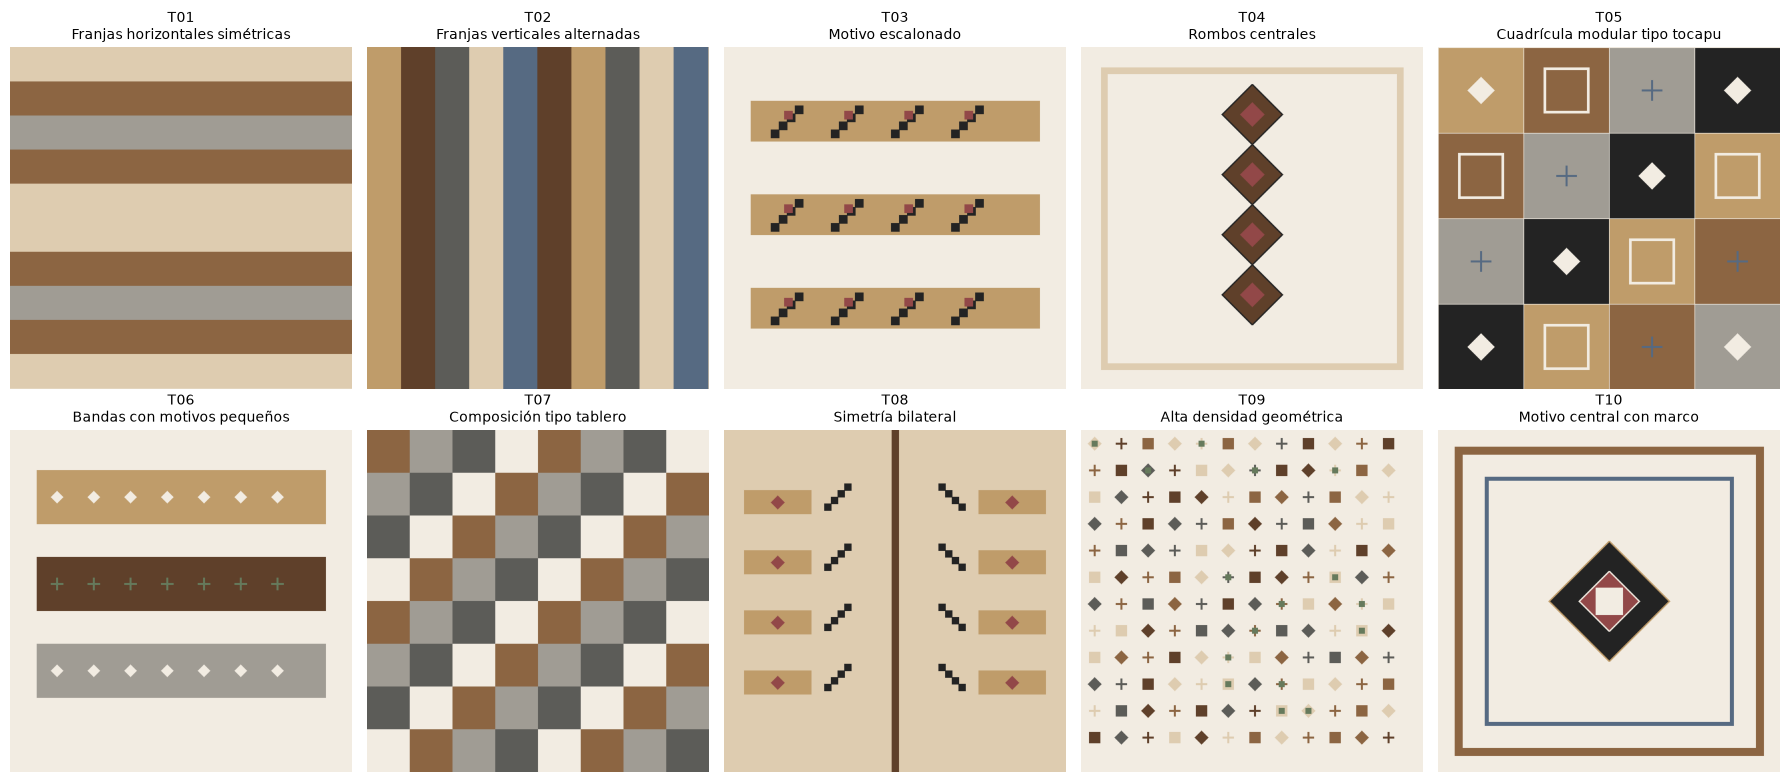

Grilla guardada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\muestra_textiles_sinteticos.png


In [93]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for ax, row in zip(axes, df.itertuples()):
    img = Image.open(row.file_path)
    ax.imshow(img)
    ax.set_title(f"{row.image_id}\n{row.nombre}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
grid_path = os.path.join(RESULTS_DIR, "muestra_textiles_sinteticos.png")
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Grilla guardada en:", grid_path)

#Construcción del conjunto textual

Aquí incluimos las 10 descripciones correctas y agregamos 5 distractoras, para que el retrieval no sea demasiado trivial.

In [94]:
correct_texts = df["descripcion_correcta"].tolist()

distractor_texts = [
    "Textil sintético con composición radial y círculos concéntricos.",
    "Diseño visual con figuras animales estilizadas y distribución dispersa.",
    "Patrón textil con diagonales cruzadas y fuerte contraste cromático.",
    "Composición de textura orgánica irregular sin repetición geométrica dominante.",
    "Textil sintético con bandas curvas ondulantes y organización fluida."
]

candidate_texts = correct_texts + distractor_texts

text_df = pd.DataFrame({
    "text_id": [f"TXT_{i+1:02d}" for i in range(len(candidate_texts))],
    "texto": candidate_texts
})

text_df

,text_id,texto
0,TXT_01,Textil andino sintético con franjas horizontal...
1,TXT_02,Textil andino sintético con franjas verticales...
2,TXT_03,Textil andino sintético con motivo geométrico ...
3,TXT_04,Textil andino sintético con rombos centrales r...
4,TXT_05,Textil andino sintético con composición modula...
5,TXT_06,Textil andino sintético con bandas decorativas...
6,TXT_07,Textil andino sintético con bloques cuadrados ...
7,TXT_08,Textil andino sintético con composición bilate...
8,TXT_09,Textil andino sintético de alta densidad geomé...
9,TXT_10,Textil andino sintético con motivo geométrico ...


#Guardado del metadata del experimento

In [95]:
metadata_path = os.path.join(DATA_DIR, "metadata_textiles.csv")
df.to_csv(metadata_path, index=False)

candidate_texts_path = os.path.join(DATA_DIR, "candidate_texts.csv")
text_df.to_csv(candidate_texts_path, index=False)

print("Metadata de imágenes guardado en:", metadata_path)
print("Textos candidatos guardados en:", candidate_texts_path)

Metadata de imágenes guardado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\metadata_textiles.csv
Textos candidatos guardados en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\candidate_texts.csv


## 5. Carga del modelo OpenCLIP

En este experimento se utiliza OpenCLIP como línea base contrastiva.

OpenCLIP no implementa ALBEF completo, pero permite reproducir la primera parte de su lógica: el alineamiento imagen-texto mediante embeddings comparables.

En términos de ALBEF, esta sección se relaciona con el objetivo ITC, Image-Text Contrastive Learning. La fusión profunda mediante ITM y MLM no se implementa en esta versión, sino que se plantea como mejora futura.

In [96]:
# ============================================================
# Carga de OpenCLIP como línea base contrastiva
# ============================================================

import torch
import open_clip

MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Modelo:", MODEL_NAME)
print("Checkpoint:", PRETRAINED)
print("Dispositivo:", device)

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED
)

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(device)
model.eval()

print("Modelo OpenCLIP cargado correctamente.")

Modelo: ViT-B-32
Checkpoint: laion2b_s34b_b79k
Dispositivo: cpu
Modelo OpenCLIP cargado correctamente.


In [97]:
# ============================================================
# Prueba mínima de codificación con OpenCLIP
# ============================================================

test_text = ["A textile pattern with geometric motifs."]

with torch.no_grad():
    test_tokens = tokenizer(test_text).to(device)
    test_text_features = model.encode_text(test_tokens)
    test_text_features = test_text_features / test_text_features.norm(dim=-1, keepdim=True)

print("Shape del embedding textual de prueba:", test_text_features.shape)

Shape del embedding textual de prueba: torch.Size([1, 512])


In [98]:
# ============================================================
# Prueba mínima de codificación de imagen
# ============================================================

image_paths = sorted([
    path for path in IMAGES_DIR.glob("T*.png")
    if path.stem in {f"T{i:02d}" for i in range(1, 11)}
])

if len(image_paths) == 0:
    raise ValueError(
        "No se encontraron imágenes T01.png a T10.png en data/images/. "
        "Ejecuta primero la celda de generación de imágenes."
    )

sample_image_path = image_paths[0]

sample_image = Image.open(sample_image_path).convert("RGB")
sample_image_tensor = preprocess(sample_image).unsqueeze(0).to(device)

with torch.no_grad():
    sample_image_features = model.encode_image(sample_image_tensor)
    sample_image_features = sample_image_features / sample_image_features.norm(dim=-1, keepdim=True)

print("Imagen de prueba:", sample_image_path.name)
print("Shape del embedding visual de prueba:", sample_image_features.shape)

Imagen de prueba: T01.png
Shape del embedding visual de prueba: torch.Size([1, 512])


## 6. Extracción de embeddings de imagen y texto

En esta sección se codifican las 10 imágenes de prueba y los 15 textos candidatos usando OpenCLIP.

Cada imagen y cada texto se transforman en un vector de 512 dimensiones.  
Luego, los embeddings se normalizan para poder comparar imagen y texto mediante producto punto, equivalente a similitud coseno.

Esta sección representa la etapa de alineamiento contrastivo usada como línea base para estudiar ALBEF.

In [99]:
# ============================================================
# Extracción de embeddings visuales
# ============================================================

image_tensors = []
image_ids = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img_tensor = preprocess(img)
    image_tensors.append(img_tensor)
    image_ids.append(path.stem)

image_batch = torch.stack(image_tensors).to(device)

with torch.no_grad():
    image_embeddings = model.encode_image(image_batch)
    image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

print("Cantidad de imágenes codificadas:", len(image_ids))
print("IDs de imagen:", image_ids)
print("Shape de embeddings de imagen:", image_embeddings.shape)

Cantidad de imágenes codificadas: 10
IDs de imagen: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10']
Shape de embeddings de imagen: torch.Size([10, 512])


#Obtención de embeddings de texto

In [100]:
# ============================================================
# Extracción de embeddings textuales
# ============================================================

text_ids = texts_df["id"].tolist()
candidate_texts = texts_df["texto"].tolist()

with torch.no_grad():
    text_tokens = tokenizer(candidate_texts).to(device)
    text_embeddings = model.encode_text(text_tokens)
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

print("Cantidad de textos codificados:", len(text_ids))
print("IDs de texto:", text_ids)
print("Shape de embeddings de texto:", text_embeddings.shape)

Cantidad de textos codificados: 15
IDs de texto: ['TXT_01', 'TXT_02', 'TXT_03', 'TXT_04', 'TXT_05', 'TXT_06', 'TXT_07', 'TXT_08', 'TXT_09', 'TXT_10', 'TXT_11', 'TXT_12', 'TXT_13', 'TXT_14', 'TXT_15']
Shape de embeddings de texto: torch.Size([15, 512])


In [101]:
# ============================================================
# Validación de dimensiones de embeddings
# ============================================================

assert image_embeddings.shape[0] == 10, "Se esperaban 10 embeddings de imagen."
assert text_embeddings.shape[0] == 15, "Se esperaban 15 embeddings de texto."
assert image_embeddings.shape[1] == text_embeddings.shape[1], "Las dimensiones de imagen y texto no coinciden."

embedding_dim = image_embeddings.shape[1]

print("Dimensión común de embeddings:", embedding_dim)
print("Validación completada: embeddings compatibles para similitud coseno.")

Dimensión común de embeddings: 512
Validación completada: embeddings compatibles para similitud coseno.


In [102]:
# ============================================================
# Conversión de embeddings a NumPy
# ============================================================

image_embeddings_np = image_embeddings.cpu().numpy()
text_embeddings_np = text_embeddings.cpu().numpy()

print("image_embeddings_np:", image_embeddings_np.shape)
print("text_embeddings_np:", text_embeddings_np.shape)

image_embeddings_np: (10, 512)
text_embeddings_np: (15, 512)


In [103]:
# ============================================================
# Metadata de embeddings
# ============================================================

embedding_metadata = pd.DataFrame({
    "objeto": ["imagenes", "textos"],
    "cantidad": [image_embeddings_np.shape[0], text_embeddings_np.shape[0]],
    "dimension_embedding": [image_embeddings_np.shape[1], text_embeddings_np.shape[1]],
    "modelo": [MODEL_NAME, MODEL_NAME],
    "checkpoint": [PRETRAINED, PRETRAINED],
})

display(embedding_metadata)

embedding_metadata_path = RESULTS_DIR / "embedding_metadata.csv"
embedding_metadata.to_csv(embedding_metadata_path, index=False, encoding="utf-8")

print("Metadata de embeddings exportada en:", embedding_metadata_path)

,objeto,cantidad,dimension_embedding,modelo,checkpoint
0,imagenes,10,512,ViT-B-32,laion2b_s34b_b79k
1,textos,15,512,ViT-B-32,laion2b_s34b_b79k


Metadata de embeddings exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\embedding_metadata.csv


## 7. Cálculo de similitud coseno

Después de obtener embeddings normalizados de imágenes y textos, se calcula la similitud entre ambas modalidades.

Como los embeddings fueron normalizados, el producto punto entre vectores equivale a similitud coseno.

Esta matriz es el núcleo del retrieval multimodal: permite ordenar los textos más cercanos a cada imagen y las imágenes más cercanas a cada texto.

In [104]:
# ============================================================
# Cálculo de similitud imagen-texto
# ============================================================

similarity_matrix = image_embeddings @ text_embeddings.T

print("Shape de la matriz de similitud:", similarity_matrix.shape)

Shape de la matriz de similitud: torch.Size([10, 15])


In [105]:
# ============================================================
# Conversión de matriz de similitud a NumPy
# ============================================================

similarity_matrix_np = similarity_matrix.cpu().numpy()

print("Matriz de similitud en NumPy:", similarity_matrix_np.shape)
print("Valor mínimo:", similarity_matrix_np.min())
print("Valor máximo:", similarity_matrix_np.max())

Matriz de similitud en NumPy: (10, 15)
Valor mínimo: 0.11072073
Valor máximo: 0.2736212


In [106]:
# ============================================================
# Matriz de similitud como DataFrame
# ============================================================

similarity_df = pd.DataFrame(
    similarity_matrix_np,
    index=image_ids,
    columns=text_ids
)

display(similarity_df.round(4))

,TXT_01,TXT_02,TXT_03,TXT_04,TXT_05,TXT_06,TXT_07,TXT_08,TXT_09,TXT_10,TXT_11,TXT_12,TXT_13,TXT_14,TXT_15
T01,0.2436,0.1989,0.2221,0.1539,0.1999,0.2081,0.2244,0.2049,0.1685,0.2208,0.1996,0.1180,0.2304,0.1877,0.2107
T02,0.2181,0.1972,0.2294,0.1296,0.1862,0.1922,0.2136,0.1946,0.1607,0.2150,0.2001,0.1107,0.2123,0.1879,0.1675
T03,0.2005,0.1731,0.2175,0.1905,0.1938,0.2290,0.2159,0.1977,0.1950,0.2231,0.1968,0.1759,0.2493,0.2004,0.2118
T04,0.1757,0.1765,0.2274,0.2010,0.1834,0.2164,0.1983,0.1840,0.2161,0.2226,0.1807,0.1429,0.2534,0.2071,0.1528
T05,0.1992,0.1813,0.2736,0.2074,0.2205,0.2312,0.2585,0.2310,0.2260,0.2580,0.2167,0.1282,0.2217,0.2071,0.1490
T06,0.2380,0.2096,0.2372,0.1946,0.2298,0.2720,0.2493,0.2248,0.2050,0.2465,0.2204,0.1898,0.2543,0.1965,0.2491
T07,0.2051,0.1836,0.2531,0.1748,0.2142,0.2044,0.2498,0.2130,0.2046,0.2270,0.2037,0.1399,0.2369,0.2272,0.1582
T08,0.2033,0.1903,0.2043,0.2006,0.1979,0.2082,0.2238,0.2190,0.1955,0.1999,0.2074,0.1559,0.2498,0.1802,0.1856
T09,0.1830,0.1706,0.2425,0.2138,0.1976,0.2207,0.2357,0.1999,0.2310,0.2263,0.1968,0.1535,0.2231,0.2080,0.1472
T10,0.1738,0.1844,0.2206,0.1950,0.1812,0.1992,0.1973,0.2097,0.1909,0.2131,0.1905,0.1361,0.2264,0.1945,0.1479


In [107]:
# ============================================================
# Exportar matriz de similitud
# ============================================================

similarity_matrix_path = RESULTS_DIR / "similarity_matrix.csv"

similarity_df.to_csv(similarity_matrix_path, encoding="utf-8")

print("Matriz de similitud exportada en:", similarity_matrix_path)

Matriz de similitud exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\similarity_matrix.csv


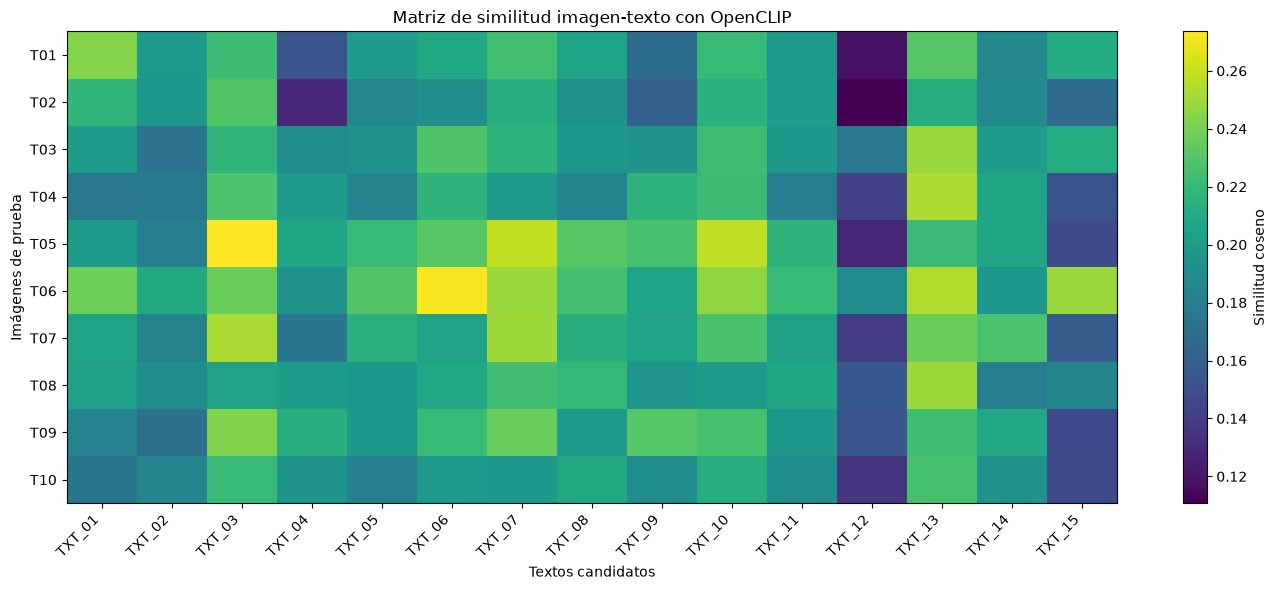

Heatmap guardado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\figures\similarity_heatmap.png


In [108]:
# ============================================================
# Guardar heatmap de similitud
# ============================================================

plt.figure(figsize=(14, 6))

plt.imshow(similarity_df.values, aspect="auto")
plt.colorbar(label="Similitud coseno")

plt.xticks(
    ticks=np.arange(len(text_ids)),
    labels=text_ids,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(image_ids)),
    labels=image_ids
)

plt.title("Matriz de similitud imagen-texto con OpenCLIP")
plt.xlabel("Textos candidatos")
plt.ylabel("Imágenes de prueba")

plt.tight_layout()

heatmap_path = FIGURES_DIR / "similarity_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Heatmap guardado en:", heatmap_path)

In [109]:
sim_matrix = cosine_similarity(image_embeddings, text_embeddings)

sim_df = pd.DataFrame(
    sim_matrix,
    index=df["image_id"].tolist(),
    columns=text_df["text_id"].tolist()
)

sim_df.head()

,TXT_01,TXT_02,TXT_03,TXT_04,TXT_05,TXT_06,TXT_07,TXT_08,TXT_09,TXT_10,TXT_11,TXT_12,TXT_13,TXT_14,TXT_15
T01,0.243603,0.198891,0.222105,0.153888,0.199909,0.208128,0.224426,0.204945,0.168486,0.220798,0.199560,0.118020,0.230369,0.187703,0.210666
T02,0.218072,0.197156,0.229396,0.129596,0.186151,0.192159,0.213604,0.194632,0.160691,0.215024,0.200144,0.110721,0.212315,0.187886,0.167451
T03,0.200451,0.173062,0.217545,0.190505,0.193819,0.229038,0.215884,0.197651,0.195038,0.223129,0.196802,0.175938,0.249295,0.200426,0.211755
T04,0.175667,0.176499,0.227376,0.200996,0.183356,0.216443,0.198320,0.183983,0.216066,0.222608,0.180695,0.142907,0.253355,0.207090,0.152811
T05,0.199171,0.181313,0.273621,0.207376,0.220504,0.231196,0.258518,0.230988,0.225999,0.258014,0.216680,0.128196,0.221657,0.207108,0.148962


In [110]:
# ============================================================
# Texto más similar para cada imagen
# ============================================================

top1_text_indices = similarity_matrix_np.argmax(axis=1)

top1_image_to_text = []

for i, text_idx in enumerate(top1_text_indices):
    image_id = image_ids[i]
    predicted_text_id = text_ids[text_idx]
    score = similarity_matrix_np[i, text_idx]
    correct_text_id = image_to_text_gt.get(image_id)
    
    top1_image_to_text.append({
        "imagen_id": image_id,
        "texto_top1": predicted_text_id,
        "texto_correcto": correct_text_id,
        "score": score,
        "correcto_top1": predicted_text_id == correct_text_id
    })

top1_image_to_text_df = pd.DataFrame(top1_image_to_text)

display(top1_image_to_text_df)

,imagen_id,texto_top1,texto_correcto,score,correcto_top1
0,T01,TXT_01,TXT_01,0.243603,True
1,T02,TXT_03,TXT_02,0.229396,False
2,T03,TXT_13,TXT_03,0.249296,False
3,T04,TXT_13,TXT_04,0.253355,False
4,T05,TXT_03,TXT_05,0.273621,False
5,T06,TXT_06,TXT_06,0.271961,True
6,T07,TXT_03,TXT_07,0.253082,False
7,T08,TXT_13,TXT_08,0.249796,False
8,T09,TXT_03,TXT_09,0.242497,False
9,T10,TXT_13,TXT_10,0.226428,False


In [111]:
# ============================================================
# Exportar Top-1 imagen → texto
# ============================================================

top1_image_to_text_path = RESULTS_DIR / "top1_image_to_text.csv"
top1_image_to_text_df.to_csv(top1_image_to_text_path, index=False, encoding="utf-8")

print("Top-1 imagen → texto exportado en:", top1_image_to_text_path)

Top-1 imagen → texto exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\top1_image_to_text.csv


## 8. Retrieval imagen → texto y texto → imagen

A partir de la matriz de similitud se generan rankings en dos direcciones:

- **Imagen → texto:** para cada imagen se ordenan los textos candidatos según similitud.
- **Texto → imagen:** para cada texto correcto se ordenan las imágenes según similitud.

Estos rankings permiten evaluar si el par correcto aparece en Top-1, Top-3 o Top-5.

In [112]:
# ============================================================
# Ranking imagen → texto
# ============================================================

def build_image_to_text_ranking(similarity_df, texts_df, image_to_text_gt, top_k=5):
    """
    Construye ranking de textos candidatos para cada imagen.
    
    Parameters
    ----------
    similarity_df : pd.DataFrame
        Matriz de similitud con imágenes como filas y textos como columnas.
    texts_df : pd.DataFrame
        DataFrame con textos candidatos.
    image_to_text_gt : dict
        Diccionario imagen_id -> texto_correcto.
    top_k : int
        Número de candidatos a mostrar por imagen.
        
    Returns
    -------
    pd.DataFrame
        Ranking imagen -> texto.
    """
    
    records = []
    
    text_lookup = texts_df.set_index("id")["texto"].to_dict()
    text_type_lookup = texts_df.set_index("id")["tipo"].to_dict()
    
    for image_id in similarity_df.index:
        scores = similarity_df.loc[image_id].sort_values(ascending=False)
        correct_text_id = image_to_text_gt.get(image_id)
        
        for rank, (text_id, score) in enumerate(scores.head(top_k).items(), start=1):
            records.append({
                "imagen_id": image_id,
                "rank": rank,
                "texto_id": text_id,
                "texto": text_lookup.get(text_id),
                "tipo_texto": text_type_lookup.get(text_id),
                "score": score,
                "texto_correcto": correct_text_id,
                "es_correcto": text_id == correct_text_id
            })
    
    return pd.DataFrame(records)


image_to_text_rankings = build_image_to_text_ranking(
    similarity_df=similarity_df,
    texts_df=texts_df,
    image_to_text_gt=image_to_text_gt,
    top_k=5
)

display(image_to_text_rankings)

,imagen_id,rank,texto_id,texto,tipo_texto,score,texto_correcto,es_correcto
0,T01,1,TXT_01,Textil andino sintético con franjas horizontal...,correcto,0.243603,TXT_01,True
1,T01,2,TXT_13,Patrón textil con diagonales cruzadas y fuerte...,distractor,0.230369,TXT_01,False
2,T01,3,TXT_07,Textil andino sintético con bloques cuadrados ...,correcto,0.224426,TXT_01,False
3,T01,4,TXT_03,Textil andino sintético con motivo geométrico ...,correcto,0.222105,TXT_01,False
4,T01,5,TXT_10,Textil andino sintético con motivo geométrico ...,correcto,0.220798,TXT_01,False
5,T02,1,TXT_03,Textil andino sintético con motivo geométrico ...,correcto,0.229396,TXT_02,False
6,T02,2,TXT_01,Textil andino sintético con franjas horizontal...,correcto,0.218072,TXT_02,False
7,T02,3,TXT_10,Textil andino sintético con motivo geométrico ...,correcto,0.215024,TXT_02,False
8,T02,4,TXT_07,Textil andino sintético con bloques cuadrados ...,correcto,0.213604,TXT_02,False
9,T02,5,TXT_13,Patrón textil con diagonales cruzadas y fuerte...,distractor,0.212315,TXT_02,False


In [113]:
# ============================================================
# Ejemplo de ranking para una imagen específica
# ============================================================

example_image_id = "T02"

display(
    image_to_text_rankings[
        image_to_text_rankings["imagen_id"] == example_image_id
    ]
)

,imagen_id,rank,texto_id,texto,tipo_texto,score,texto_correcto,es_correcto
5,T02,1,TXT_03,Textil andino sintético con motivo geométrico ...,correcto,0.229396,TXT_02,False
6,T02,2,TXT_01,Textil andino sintético con franjas horizontal...,correcto,0.218072,TXT_02,False
7,T02,3,TXT_10,Textil andino sintético con motivo geométrico ...,correcto,0.215024,TXT_02,False
8,T02,4,TXT_07,Textil andino sintético con bloques cuadrados ...,correcto,0.213604,TXT_02,False
9,T02,5,TXT_13,Patrón textil con diagonales cruzadas y fuerte...,distractor,0.212315,TXT_02,False


In [114]:
# ============================================================
# Exportar ranking imagen → texto
# ============================================================

image_to_text_rankings_path = RESULTS_DIR / "image_to_text_rankings_top5.csv"

image_to_text_rankings.to_csv(
    image_to_text_rankings_path,
    index=False,
    encoding="utf-8"
)

print("Ranking imagen → texto exportado en:", image_to_text_rankings_path)

Ranking imagen → texto exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\image_to_text_rankings_top5.csv


In [115]:
# ============================================================
# Ranking texto → imagen
# ============================================================

def build_text_to_image_ranking(similarity_df, texts_df, text_to_image_gt, top_k=5):
    """
    Construye ranking de imágenes candidatas para cada texto correcto.
    
    Solo se evalúan textos correctos, porque los distractores no tienen imagen esperada.
    
    Parameters
    ----------
    similarity_df : pd.DataFrame
        Matriz de similitud con imágenes como filas y textos como columnas.
    texts_df : pd.DataFrame
        DataFrame con textos candidatos.
    text_to_image_gt : dict
        Diccionario texto_id -> imagen_correcta.
    top_k : int
        Número de candidatos a mostrar por texto.
        
    Returns
    -------
    pd.DataFrame
        Ranking texto -> imagen.
    """
    
    records = []
    text_lookup = texts_df.set_index("id")["texto"].to_dict()
    
    correct_text_ids = list(text_to_image_gt.keys())
    
    for text_id in correct_text_ids:
        scores = similarity_df[text_id].sort_values(ascending=False)
        correct_image_id = text_to_image_gt.get(text_id)
        
        for rank, (image_id, score) in enumerate(scores.head(top_k).items(), start=1):
            records.append({
                "texto_id": text_id,
                "texto": text_lookup.get(text_id),
                "rank": rank,
                "imagen_id": image_id,
                "score": score,
                "imagen_correcta": correct_image_id,
                "es_correcto": image_id == correct_image_id
            })
    
    return pd.DataFrame(records)


text_to_image_rankings = build_text_to_image_ranking(
    similarity_df=similarity_df,
    texts_df=texts_df,
    text_to_image_gt=text_to_image_gt,
    top_k=5
)

display(text_to_image_rankings)

,texto_id,texto,rank,imagen_id,score,imagen_correcta,es_correcto
0,TXT_01,Textil andino sintético con franjas horizontal...,1,T01,0.243603,T01,True
1,TXT_01,Textil andino sintético con franjas horizontal...,2,T06,0.237980,T01,False
2,TXT_01,Textil andino sintético con franjas horizontal...,3,T02,0.218072,T01,False
3,TXT_01,Textil andino sintético con franjas horizontal...,4,T07,0.205079,T01,False
4,TXT_01,Textil andino sintético con franjas horizontal...,5,T08,0.203334,T01,False
5,TXT_02,Textil andino sintético con franjas verticales...,1,T06,0.209558,T02,False
6,TXT_02,Textil andino sintético con franjas verticales...,2,T01,0.198891,T02,False
7,TXT_02,Textil andino sintético con franjas verticales...,3,T02,0.197156,T02,True
8,TXT_02,Textil andino sintético con franjas verticales...,4,T08,0.190336,T02,False
9,TXT_02,Textil andino sintético con franjas verticales...,5,T10,0.184446,T02,False


In [116]:
# ============================================================
# Ejemplo de ranking para un texto específico
# ============================================================

example_text_id = "TXT_01"

display(
    text_to_image_rankings[
        text_to_image_rankings["texto_id"] == example_text_id
    ]
)

,texto_id,texto,rank,imagen_id,score,imagen_correcta,es_correcto
0,TXT_01,Textil andino sintético con franjas horizontal...,1,T01,0.243603,T01,True
1,TXT_01,Textil andino sintético con franjas horizontal...,2,T06,0.237980,T01,False
2,TXT_01,Textil andino sintético con franjas horizontal...,3,T02,0.218072,T01,False
3,TXT_01,Textil andino sintético con franjas horizontal...,4,T07,0.205079,T01,False
4,TXT_01,Textil andino sintético con franjas horizontal...,5,T08,0.203334,T01,False


In [117]:
# ============================================================
# Exportar ranking texto → imagen
# ============================================================

text_to_image_rankings_path = RESULTS_DIR / "text_to_image_rankings_top5.csv"

text_to_image_rankings.to_csv(
    text_to_image_rankings_path,
    index=False,
    encoding="utf-8"
)

print("Ranking texto → imagen exportado en:", text_to_image_rankings_path)

Ranking texto → imagen exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\text_to_image_rankings_top5.csv


In [118]:
# ============================================================
# Resumen Top-1 imagen → texto y texto → imagen
# ============================================================

image_to_text_top1 = (
    image_to_text_rankings[image_to_text_rankings["rank"] == 1]
    .copy()
    .reset_index(drop=True)
)

text_to_image_top1 = (
    text_to_image_rankings[text_to_image_rankings["rank"] == 1]
    .copy()
    .reset_index(drop=True)
)

print("Top-1 imagen → texto")
display(image_to_text_top1[[
    "imagen_id", "texto_id", "texto_correcto", "score", "es_correcto"
]])

print("Top-1 texto → imagen")
display(text_to_image_top1[[
    "texto_id", "imagen_id", "imagen_correcta", "score", "es_correcto"
]])

Top-1 imagen → texto


,imagen_id,texto_id,texto_correcto,score,es_correcto
0,T01,TXT_01,TXT_01,0.243603,True
1,T02,TXT_03,TXT_02,0.229396,False
2,T03,TXT_13,TXT_03,0.249296,False
3,T04,TXT_13,TXT_04,0.253355,False
4,T05,TXT_03,TXT_05,0.273621,False
5,T06,TXT_06,TXT_06,0.271961,True
6,T07,TXT_03,TXT_07,0.253082,False
7,T08,TXT_13,TXT_08,0.249796,False
8,T09,TXT_03,TXT_09,0.242497,False
9,T10,TXT_13,TXT_10,0.226428,False


Top-1 texto → imagen


,texto_id,imagen_id,imagen_correcta,score,es_correcto
0,TXT_01,T01,T01,0.243603,True
1,TXT_02,T06,T02,0.209558,False
2,TXT_03,T05,T03,0.273621,False
3,TXT_04,T09,T04,0.213768,False
4,TXT_05,T06,T05,0.229801,False
5,TXT_06,T06,T06,0.271961,True
6,TXT_07,T05,T07,0.258518,False
7,TXT_08,T05,T08,0.230988,False
8,TXT_09,T09,T09,0.230971,True
9,TXT_10,T05,T10,0.258014,False


In [119]:
# ============================================================
# Exportar resumen Top-1
# ============================================================

image_to_text_top1_path = RESULTS_DIR / "image_to_text_top1.csv"
text_to_image_top1_path = RESULTS_DIR / "text_to_image_top1.csv"

image_to_text_top1.to_csv(image_to_text_top1_path, index=False, encoding="utf-8")
text_to_image_top1.to_csv(text_to_image_top1_path, index=False, encoding="utf-8")

print("Top-1 imagen → texto exportado en:", image_to_text_top1_path)
print("Top-1 texto → imagen exportado en:", text_to_image_top1_path)

Top-1 imagen → texto exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\image_to_text_top1.csv
Top-1 texto → imagen exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\text_to_image_top1.csv


### Lectura inicial de rankings

Los rankings permiten observar si el modelo recupera el par correcto en las primeras posiciones.

Un acierto en Top-1 indica que el texto o imagen correcta fue recuperado como primera opción.  
Un acierto en Top-5 indica que el modelo no acertó necesariamente en la primera posición, pero sí ubicó el par correcto entre los candidatos más cercanos.

Este punto es importante para ALBEF: si el par correcto aparece en Top-5 pero no en Top-1, entonces una segunda etapa de re-ranking con fusión crossmodal podría mejorar el orden final.

## 9. Métricas Recall@K

Recall@K mide si el par correcto aparece dentro de los primeros K resultados recuperados.

En este experimento se evalúan dos direcciones:

- **Imagen → texto:** dada una imagen, verificar si su texto correcto aparece en Top-K.
- **Texto → imagen:** dado un texto correcto, verificar si su imagen correspondiente aparece en Top-K.

Estas métricas permiten evaluar la calidad del alineamiento imagen-texto producido por OpenCLIP.

In [120]:
# ============================================================
# Recall@K para imagen → texto
# ============================================================

def recall_at_k_image_to_text(similarity_df, image_to_text_gt, k=1):
    """
    Calcula Recall@K para recuperación imagen -> texto.
    
    Para cada imagen, verifica si el texto correcto aparece dentro
    de los primeros K textos recuperados.
    """
    
    hits = []
    
    for image_id in similarity_df.index:
        correct_text_id = image_to_text_gt.get(image_id)
        top_k_texts = (
            similarity_df.loc[image_id]
            .sort_values(ascending=False)
            .head(k)
            .index
            .tolist()
        )
        
        hit = correct_text_id in top_k_texts
        
        hits.append({
            "imagen_id": image_id,
            "texto_correcto": correct_text_id,
            "top_k": top_k_texts,
            "k": k,
            "hit": hit
        })
    
    recall = np.mean([item["hit"] for item in hits])
    
    return recall, pd.DataFrame(hits)

In [121]:
# ============================================================
# Recall@K para texto → imagen
# ============================================================

def recall_at_k_text_to_image(similarity_df, text_to_image_gt, k=1):
    """
    Calcula Recall@K para recuperación texto -> imagen.
    
    Para cada texto correcto, verifica si la imagen correcta aparece
    dentro de las primeras K imágenes recuperadas.
    """
    
    hits = []
    
    for text_id, correct_image_id in text_to_image_gt.items():
        top_k_images = (
            similarity_df[text_id]
            .sort_values(ascending=False)
            .head(k)
            .index
            .tolist()
        )
        
        hit = correct_image_id in top_k_images
        
        hits.append({
            "texto_id": text_id,
            "imagen_correcta": correct_image_id,
            "top_k": top_k_images,
            "k": k,
            "hit": hit
        })
    
    recall = np.mean([item["hit"] for item in hits])
    
    return recall, pd.DataFrame(hits)

In [122]:
# ============================================================
# Cálculo de métricas Recall@K
# ============================================================

ks = [1, 3, 5]

metrics_records = []
image_to_text_hit_details = {}
text_to_image_hit_details = {}

for k in ks:
    recall_i2t, details_i2t = recall_at_k_image_to_text(
        similarity_df=similarity_df,
        image_to_text_gt=image_to_text_gt,
        k=k
    )
    
    recall_t2i, details_t2i = recall_at_k_text_to_image(
        similarity_df=similarity_df,
        text_to_image_gt=text_to_image_gt,
        k=k
    )
    
    image_to_text_hit_details[k] = details_i2t
    text_to_image_hit_details[k] = details_t2i
    
    metrics_records.append({
        "direccion": "imagen_a_texto",
        "k": k,
        "recall": recall_i2t
    })
    
    metrics_records.append({
        "direccion": "texto_a_imagen",
        "k": k,
        "recall": recall_t2i
    })

metrics_df = pd.DataFrame(metrics_records)

display(metrics_df)

,direccion,k,recall
0,imagen_a_texto,1,0.2
1,texto_a_imagen,1,0.3
2,imagen_a_texto,3,0.6
3,texto_a_imagen,3,0.8
4,imagen_a_texto,5,0.7
5,texto_a_imagen,5,0.8


In [123]:
# ============================================================
# Tabla compacta de métricas
# ============================================================

metrics_pivot = (
    metrics_df
    .pivot(index="direccion", columns="k", values="recall")
    .reset_index()
)

metrics_pivot.columns = ["direccion", "Recall@1", "Recall@3", "Recall@5"]

display(metrics_pivot)

,direccion,Recall@1,Recall@3,Recall@5
0,imagen_a_texto,0.2,0.6,0.7
1,texto_a_imagen,0.3,0.8,0.8


In [124]:
# ============================================================
# Exportar métricas
# ============================================================

metrics_path = RESULTS_DIR / "recall_metrics.csv"
metrics_pivot_path = RESULTS_DIR / "recall_metrics_pivot.csv"

metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")
metrics_pivot.to_csv(metrics_pivot_path, index=False, encoding="utf-8")

print("Métricas exportadas en:", metrics_path)
print("Tabla compacta exportada en:", metrics_pivot_path)

Métricas exportadas en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\recall_metrics.csv
Tabla compacta exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\recall_metrics_pivot.csv


In [125]:
# ============================================================
# Detalle de aciertos en Top-5
# ============================================================

print("Detalle imagen → texto, Recall@5")
display(image_to_text_hit_details[5])

print("Detalle texto → imagen, Recall@5")
display(text_to_image_hit_details[5])

Detalle imagen → texto, Recall@5


,imagen_id,texto_correcto,top_k,k,hit
0,T01,TXT_01,"[TXT_01, TXT_13, TXT_07, TXT_03, TXT_10]",5,True
1,T02,TXT_02,"[TXT_03, TXT_01, TXT_10, TXT_07, TXT_13]",5,False
2,T03,TXT_03,"[TXT_13, TXT_06, TXT_10, TXT_03, TXT_07]",5,True
3,T04,TXT_04,"[TXT_13, TXT_03, TXT_10, TXT_06, TXT_09]",5,False
4,T05,TXT_05,"[TXT_03, TXT_07, TXT_10, TXT_06, TXT_08]",5,False
5,T06,TXT_06,"[TXT_06, TXT_13, TXT_07, TXT_15, TXT_10]",5,True
6,T07,TXT_07,"[TXT_03, TXT_07, TXT_13, TXT_14, TXT_10]",5,True
7,T08,TXT_08,"[TXT_13, TXT_07, TXT_08, TXT_06, TXT_11]",5,True
8,T09,TXT_09,"[TXT_03, TXT_07, TXT_09, TXT_10, TXT_13]",5,True
9,T10,TXT_10,"[TXT_13, TXT_03, TXT_10, TXT_08, TXT_06]",5,True


Detalle texto → imagen, Recall@5


,texto_id,imagen_correcta,top_k,k,hit
0,TXT_01,T01,"[T01, T06, T02, T07, T08]",5,True
1,TXT_02,T02,"[T06, T01, T02, T08, T10]",5,True
2,TXT_03,T03,"[T05, T07, T09, T06, T02]",5,False
3,TXT_04,T04,"[T09, T05, T04, T08, T10]",5,True
4,TXT_05,T05,"[T06, T05, T07, T01, T08]",5,True
5,TXT_06,T06,"[T06, T05, T03, T09, T04]",5,True
6,TXT_07,T07,"[T05, T07, T06, T09, T01]",5,True
7,TXT_08,T08,"[T05, T06, T08, T07, T10]",5,True
8,TXT_09,T09,"[T09, T05, T04, T06, T07]",5,True
9,TXT_10,T10,"[T05, T06, T07, T09, T03]",5,False


In [126]:
# ============================================================
# Interpretación breve de resultados
# ============================================================

r_i2t_1 = metrics_pivot.loc[metrics_pivot["direccion"] == "imagen_a_texto", "Recall@1"].values[0]
r_i2t_3 = metrics_pivot.loc[metrics_pivot["direccion"] == "imagen_a_texto", "Recall@3"].values[0]
r_i2t_5 = metrics_pivot.loc[metrics_pivot["direccion"] == "imagen_a_texto", "Recall@5"].values[0]

r_t2i_1 = metrics_pivot.loc[metrics_pivot["direccion"] == "texto_a_imagen", "Recall@1"].values[0]
r_t2i_3 = metrics_pivot.loc[metrics_pivot["direccion"] == "texto_a_imagen", "Recall@3"].values[0]
r_t2i_5 = metrics_pivot.loc[metrics_pivot["direccion"] == "texto_a_imagen", "Recall@5"].values[0]

print("Interpretación preliminar:")
print(f"- Imagen → texto: Recall@1 = {r_i2t_1:.2f}, Recall@3 = {r_i2t_3:.2f}, Recall@5 = {r_i2t_5:.2f}")
print(f"- Texto → imagen: Recall@1 = {r_t2i_1:.2f}, Recall@3 = {r_t2i_3:.2f}, Recall@5 = {r_t2i_5:.2f}")

if r_i2t_5 > r_i2t_1:
    print("- En imagen → texto, el aumento de Recall@5 frente a Recall@1 sugiere que el modelo encuentra candidatos relevantes, aunque no siempre en la primera posición.")

if r_t2i_5 > r_t2i_1:
    print("- En texto → imagen, el aumento de Recall@5 frente a Recall@1 sugiere que el alineamiento tiene señal útil, pero aún requiere mejorar el ordenamiento.")

Interpretación preliminar:
- Imagen → texto: Recall@1 = 0.20, Recall@3 = 0.60, Recall@5 = 0.70
- Texto → imagen: Recall@1 = 0.30, Recall@3 = 0.80, Recall@5 = 0.80
- En imagen → texto, el aumento de Recall@5 frente a Recall@1 sugiere que el modelo encuentra candidatos relevantes, aunque no siempre en la primera posición.
- En texto → imagen, el aumento de Recall@5 frente a Recall@1 sugiere que el alineamiento tiene señal útil, pero aún requiere mejorar el ordenamiento.


### Interpretación

Las métricas Recall@K permiten medir si el par correcto aparece entre los primeros resultados recuperados.

Si Recall@1 es bajo pero Recall@5 mejora, significa que el modelo encuentra candidatos razonables, pero todavía no siempre ordena correctamente el resultado más pertinente.

Este resultado es importante para la lectura de ALBEF: una línea base contrastiva como OpenCLIP puede recuperar candidatos, pero una etapa posterior de re-ranking con fusión crossmodal podría mejorar el orden final.

## 10. Análisis de errores y hard negatives

En esta sección se analizan los errores del retrieval.

Un error ocurre cuando el par correcto no aparece en Top-1 o no aparece dentro del Top-K evaluado.

También se identifican hard negatives: candidatos incorrectos que aparecen en posiciones altas del ranking porque son visual o semánticamente parecidos al par correcto.

Este análisis es importante porque muestra una limitación de la línea base contrastiva con OpenCLIP y justifica la mejora propuesta por ALBEF: usar una segunda etapa de fusión crossmodal o re-ranking.

In [127]:
# ============================================================
# Posición real del texto correcto en imagen → texto
# ============================================================

def get_correct_rank_image_to_text(similarity_df, texts_df, image_to_text_gt):
    records = []
    
    text_lookup = texts_df.set_index("id")["texto"].to_dict()
    text_type_lookup = texts_df.set_index("id")["tipo"].to_dict()
    
    for image_id in similarity_df.index:
        correct_text_id = image_to_text_gt.get(image_id)
        
        ranked_scores = similarity_df.loc[image_id].sort_values(ascending=False)
        ranked_text_ids = ranked_scores.index.tolist()
        
        correct_rank = ranked_text_ids.index(correct_text_id) + 1
        top1_text_id = ranked_text_ids[0]
        
        records.append({
            "imagen_id": image_id,
            "texto_correcto": correct_text_id,
            "rank_texto_correcto": correct_rank,
            "score_texto_correcto": ranked_scores[correct_text_id],
            "texto_top1": top1_text_id,
            "tipo_top1": text_type_lookup.get(top1_text_id),
            "score_top1": ranked_scores[top1_text_id],
            "top1_es_correcto": top1_text_id == correct_text_id,
            "gap_top1_vs_correcto": ranked_scores[top1_text_id] - ranked_scores[correct_text_id],
            "texto_top1_descripcion": text_lookup.get(top1_text_id),
            "texto_correcto_descripcion": text_lookup.get(correct_text_id)
        })
    
    return pd.DataFrame(records)


error_i2t_df = get_correct_rank_image_to_text(
    similarity_df=similarity_df,
    texts_df=texts_df,
    image_to_text_gt=image_to_text_gt
)

display(error_i2t_df)

,imagen_id,texto_correcto,rank_texto_correcto,score_texto_correcto,texto_top1,tipo_top1,score_top1,top1_es_correcto,gap_top1_vs_correcto,texto_top1_descripcion,texto_correcto_descripcion
0,T01,TXT_01,1,0.243603,TXT_01,correcto,0.243603,True,0.000000,Textil andino sintético con franjas horizontal...,Textil andino sintético con franjas horizontal...
1,T02,TXT_02,7,0.197156,TXT_03,correcto,0.229396,False,0.032240,Textil andino sintético con motivo geométrico ...,Textil andino sintético con franjas verticales...
2,T03,TXT_03,4,0.217545,TXT_13,distractor,0.249296,False,0.031750,Patrón textil con diagonales cruzadas y fuerte...,Textil andino sintético con motivo geométrico ...
3,T04,TXT_04,7,0.200996,TXT_13,distractor,0.253355,False,0.052359,Patrón textil con diagonales cruzadas y fuerte...,Textil andino sintético con rombos centrales r...
4,T05,TXT_05,8,0.220504,TXT_03,correcto,0.273621,False,0.053118,Textil andino sintético con motivo geométrico ...,Textil andino sintético con composición modula...
5,T06,TXT_06,1,0.271961,TXT_06,correcto,0.271961,True,0.000000,Textil andino sintético con bandas decorativas...,Textil andino sintético con bandas decorativas...
6,T07,TXT_07,2,0.249768,TXT_03,correcto,0.253082,False,0.003314,Textil andino sintético con motivo geométrico ...,Textil andino sintético con bloques cuadrados ...
7,T08,TXT_08,3,0.218957,TXT_13,distractor,0.249796,False,0.030839,Patrón textil con diagonales cruzadas y fuerte...,Textil andino sintético con composición bilate...
8,T09,TXT_09,3,0.230971,TXT_03,correcto,0.242497,False,0.011526,Textil andino sintético con motivo geométrico ...,Textil andino sintético de alta densidad geomé...
9,T10,TXT_10,3,0.213067,TXT_13,distractor,0.226428,False,0.013361,Patrón textil con diagonales cruzadas y fuerte...,Textil andino sintético con motivo geométrico ...


In [128]:
# ============================================================
# Casos fallidos imagen → texto
# ============================================================

errors_i2t_df = error_i2t_df[error_i2t_df["top1_es_correcto"] == False].copy()

print("Número de errores Top-1 imagen → texto:", len(errors_i2t_df))
display(errors_i2t_df[[
    "imagen_id",
    "texto_correcto",
    "rank_texto_correcto",
    "texto_top1",
    "tipo_top1",
    "score_top1",
    "score_texto_correcto",
    "gap_top1_vs_correcto"
]])

Número de errores Top-1 imagen → texto: 8


,imagen_id,texto_correcto,rank_texto_correcto,texto_top1,tipo_top1,score_top1,score_texto_correcto,gap_top1_vs_correcto
1,T02,TXT_02,7,TXT_03,correcto,0.229396,0.197156,0.032240
2,T03,TXT_03,4,TXT_13,distractor,0.249296,0.217545,0.031750
3,T04,TXT_04,7,TXT_13,distractor,0.253355,0.200996,0.052359
4,T05,TXT_05,8,TXT_03,correcto,0.273621,0.220504,0.053118
6,T07,TXT_07,2,TXT_03,correcto,0.253082,0.249768,0.003314
7,T08,TXT_08,3,TXT_13,distractor,0.249796,0.218957,0.030839
8,T09,TXT_09,3,TXT_03,correcto,0.242497,0.230971,0.011526
9,T10,TXT_10,3,TXT_13,distractor,0.226428,0.213067,0.013361


In [129]:
# ============================================================
# Posición real de la imagen correcta en texto → imagen
# ============================================================

def get_correct_rank_text_to_image(similarity_df, texts_df, text_to_image_gt):
    records = []
    
    text_lookup = texts_df.set_index("id")["texto"].to_dict()
    
    for text_id, correct_image_id in text_to_image_gt.items():
        ranked_scores = similarity_df[text_id].sort_values(ascending=False)
        ranked_image_ids = ranked_scores.index.tolist()
        
        correct_rank = ranked_image_ids.index(correct_image_id) + 1
        top1_image_id = ranked_image_ids[0]
        
        records.append({
            "texto_id": text_id,
            "texto": text_lookup.get(text_id),
            "imagen_correcta": correct_image_id,
            "rank_imagen_correcta": correct_rank,
            "score_imagen_correcta": ranked_scores[correct_image_id],
            "imagen_top1": top1_image_id,
            "score_top1": ranked_scores[top1_image_id],
            "top1_es_correcto": top1_image_id == correct_image_id,
            "gap_top1_vs_correcto": ranked_scores[top1_image_id] - ranked_scores[correct_image_id]
        })
    
    return pd.DataFrame(records)


error_t2i_df = get_correct_rank_text_to_image(
    similarity_df=similarity_df,
    texts_df=texts_df,
    text_to_image_gt=text_to_image_gt
)

display(error_t2i_df)

,texto_id,texto,imagen_correcta,rank_imagen_correcta,score_imagen_correcta,imagen_top1,score_top1,top1_es_correcto,gap_top1_vs_correcto
0,TXT_01,Textil andino sintético con franjas horizontal...,T01,1,0.243603,T01,0.243603,True,0.000000
1,TXT_02,Textil andino sintético con franjas verticales...,T02,3,0.197156,T06,0.209558,False,0.012402
2,TXT_03,Textil andino sintético con motivo geométrico ...,T03,9,0.217545,T05,0.273621,False,0.056076
3,TXT_04,Textil andino sintético con rombos centrales r...,T04,3,0.200996,T09,0.213768,False,0.012771
4,TXT_05,Textil andino sintético con composición modula...,T05,2,0.220504,T06,0.229801,False,0.009297
5,TXT_06,Textil andino sintético con bandas decorativas...,T06,1,0.271961,T06,0.271961,True,0.000000
6,TXT_07,Textil andino sintético con bloques cuadrados ...,T07,2,0.249768,T05,0.258518,False,0.008749
7,TXT_08,Textil andino sintético con composición bilate...,T08,3,0.218957,T05,0.230988,False,0.012031
8,TXT_09,Textil andino sintético de alta densidad geomé...,T09,1,0.230971,T09,0.230971,True,0.000000
9,TXT_10,Textil andino sintético con motivo geométrico ...,T10,9,0.213067,T05,0.258014,False,0.044947


In [130]:
# ============================================================
# Casos fallidos texto → imagen
# ============================================================

errors_t2i_df = error_t2i_df[error_t2i_df["top1_es_correcto"] == False].copy()

print("Número de errores Top-1 texto → imagen:", len(errors_t2i_df))
display(errors_t2i_df[[
    "texto_id",
    "imagen_correcta",
    "rank_imagen_correcta",
    "imagen_top1",
    "score_top1",
    "score_imagen_correcta",
    "gap_top1_vs_correcto"
]])

Número de errores Top-1 texto → imagen: 7


,texto_id,imagen_correcta,rank_imagen_correcta,imagen_top1,score_top1,score_imagen_correcta,gap_top1_vs_correcto
1,TXT_02,T02,3,T06,0.209558,0.197156,0.012402
2,TXT_03,T03,9,T05,0.273621,0.217545,0.056076
3,TXT_04,T04,3,T09,0.213768,0.200996,0.012771
4,TXT_05,T05,2,T06,0.229801,0.220504,0.009297
6,TXT_07,T07,2,T05,0.258518,0.249768,0.008749
7,TXT_08,T08,3,T05,0.230988,0.218957,0.012031
9,TXT_10,T10,9,T05,0.258014,0.213067,0.044947


In [131]:
# ============================================================
# Hard negatives en imagen → texto
# ============================================================

hard_negatives_i2t = image_to_text_rankings[
    image_to_text_rankings["es_correcto"] == False
].copy()

# Nos interesan los incorrectos que aparecen muy arriba
hard_negatives_i2t_top3 = hard_negatives_i2t[
    hard_negatives_i2t["rank"] <= 3
].copy()

print("Hard negatives imagen → texto dentro del Top-3:", len(hard_negatives_i2t_top3))

display(hard_negatives_i2t_top3[[
    "imagen_id",
    "rank",
    "texto_id",
    "tipo_texto",
    "score",
    "texto_correcto",
    "texto"
]])

Hard negatives imagen → texto dentro del Top-3: 24


,imagen_id,rank,texto_id,tipo_texto,score,texto_correcto,texto
1,T01,2,TXT_13,distractor,0.230369,TXT_01,Patrón textil con diagonales cruzadas y fuerte...
2,T01,3,TXT_07,correcto,0.224426,TXT_01,Textil andino sintético con bloques cuadrados ...
5,T02,1,TXT_03,correcto,0.229396,TXT_02,Textil andino sintético con motivo geométrico ...
6,T02,2,TXT_01,correcto,0.218072,TXT_02,Textil andino sintético con franjas horizontal...
7,T02,3,TXT_10,correcto,0.215024,TXT_02,Textil andino sintético con motivo geométrico ...
10,T03,1,TXT_13,distractor,0.249296,TXT_03,Patrón textil con diagonales cruzadas y fuerte...
11,T03,2,TXT_06,correcto,0.229038,TXT_03,Textil andino sintético con bandas decorativas...
12,T03,3,TXT_10,correcto,0.223129,TXT_03,Textil andino sintético con motivo geométrico ...
15,T04,1,TXT_13,distractor,0.253355,TXT_04,Patrón textil con diagonales cruzadas y fuerte...
16,T04,2,TXT_03,correcto,0.227376,TXT_04,Textil andino sintético con motivo geométrico ...


In [132]:
# ============================================================
# Frecuencia de textos incorrectos recuperados como hard negatives
# ============================================================

hard_negative_frequency_i2t = (
    hard_negatives_i2t_top3
    .groupby(["texto_id", "tipo_texto"])
    .size()
    .reset_index(name="frecuencia_top3")
    .sort_values("frecuencia_top3", ascending=False)
)

display(hard_negative_frequency_i2t)

,texto_id,tipo_texto,frecuencia_top3
5,TXT_13,distractor,7
1,TXT_03,correcto,6
3,TXT_07,correcto,5
4,TXT_10,correcto,4
0,TXT_01,correcto,1
2,TXT_06,correcto,1


In [133]:
# ============================================================
# Hard negatives en texto → imagen
# ============================================================

hard_negatives_t2i = text_to_image_rankings[
    text_to_image_rankings["es_correcto"] == False
].copy()

hard_negatives_t2i_top3 = hard_negatives_t2i[
    hard_negatives_t2i["rank"] <= 3
].copy()

print("Hard negatives texto → imagen dentro del Top-3:", len(hard_negatives_t2i_top3))

display(hard_negatives_t2i_top3[[
    "texto_id",
    "rank",
    "imagen_id",
    "score",
    "imagen_correcta",
    "texto"
]])

Hard negatives texto → imagen dentro del Top-3: 22


,texto_id,rank,imagen_id,score,imagen_correcta,texto
1,TXT_01,2,T06,0.237980,T01,Textil andino sintético con franjas horizontal...
2,TXT_01,3,T02,0.218072,T01,Textil andino sintético con franjas horizontal...
5,TXT_02,1,T06,0.209558,T02,Textil andino sintético con franjas verticales...
6,TXT_02,2,T01,0.198891,T02,Textil andino sintético con franjas verticales...
10,TXT_03,1,T05,0.273621,T03,Textil andino sintético con motivo geométrico ...
11,TXT_03,2,T07,0.253082,T03,Textil andino sintético con motivo geométrico ...
12,TXT_03,3,T09,0.242497,T03,Textil andino sintético con motivo geométrico ...
15,TXT_04,1,T09,0.213768,T04,Textil andino sintético con rombos centrales r...
16,TXT_04,2,T05,0.207376,T04,Textil andino sintético con rombos centrales r...
20,TXT_05,1,T06,0.229801,T05,Textil andino sintético con composición modula...


In [134]:
# ============================================================
# Frecuencia de imágenes incorrectas recuperadas como hard negatives
# ============================================================

hard_negative_frequency_t2i = (
    hard_negatives_t2i_top3
    .groupby("imagen_id")
    .size()
    .reset_index(name="frecuencia_top3")
    .sort_values("frecuencia_top3", ascending=False)
)

display(hard_negative_frequency_t2i)

,imagen_id,frecuencia_top3
4,T05,7
5,T06,6
6,T07,3
7,T09,2
3,T04,1
2,T03,1
1,T02,1
0,T01,1


In [135]:
# ============================================================
# Exportar análisis de errores y hard negatives
# ============================================================

error_i2t_path = RESULTS_DIR / "error_analysis_image_to_text.csv"
error_t2i_path = RESULTS_DIR / "error_analysis_text_to_image.csv"
hard_neg_i2t_path = RESULTS_DIR / "hard_negatives_image_to_text_top3.csv"
hard_neg_t2i_path = RESULTS_DIR / "hard_negatives_text_to_image_top3.csv"
hard_neg_freq_i2t_path = RESULTS_DIR / "hard_negative_frequency_image_to_text.csv"
hard_neg_freq_t2i_path = RESULTS_DIR / "hard_negative_frequency_text_to_image.csv"

error_i2t_df.to_csv(error_i2t_path, index=False, encoding="utf-8")
error_t2i_df.to_csv(error_t2i_path, index=False, encoding="utf-8")
hard_negatives_i2t_top3.to_csv(hard_neg_i2t_path, index=False, encoding="utf-8")
hard_negatives_t2i_top3.to_csv(hard_neg_t2i_path, index=False, encoding="utf-8")
hard_negative_frequency_i2t.to_csv(hard_neg_freq_i2t_path, index=False, encoding="utf-8")
hard_negative_frequency_t2i.to_csv(hard_neg_freq_t2i_path, index=False, encoding="utf-8")

print("Archivos exportados:")
print(error_i2t_path)
print(error_t2i_path)
print(hard_neg_i2t_path)
print(hard_neg_t2i_path)
print(hard_neg_freq_i2t_path)
print(hard_neg_freq_t2i_path)

Archivos exportados:
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\error_analysis_image_to_text.csv
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\error_analysis_text_to_image.csv
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\hard_negatives_image_to_text_top3.csv
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\hard_negatives_text_to_image_top3.csv
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\hard_negative_frequency_image_to_text.csv
d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\hard_negative_frequency_text_to_image.csv


### Interpretación de errores

Los resultados muestran que OpenCLIP logra recuperar señal semántica útil, especialmente en Top-5, pero no siempre ordena correctamente el primer resultado.

En imagen → texto se obtuvo Recall@1 = 0.20 y Recall@5 = 0.70. Esto indica que, aunque el texto correcto aparece entre los primeros cinco candidatos en varios casos, el modelo suele ubicar textos incorrectos por encima del correcto.

En texto → imagen se obtuvo Recall@1 = 0.30 y Recall@5 = 0.80. Esto sugiere que la consulta textual permite recuperar imágenes razonablemente cercanas, pero todavía existen confusiones entre patrones visualmente similares.

Los errores son útiles para el análisis de ALBEF porque muestran una limitación de la comparación global por embeddings. Cuando un distractor aparece en posiciones altas, el modelo reconoce cercanía semántica general, pero no necesariamente distingue detalles finos del patrón.

Por ello, una mejora natural sería incorporar una etapa de re-ranking con fusión crossmodal, donde el modelo revise con mayor detalle los pares imagen-texto recuperados.

In [136]:
# ============================================================
# Resumen crítico del análisis de errores
# ============================================================

critical_reading = pd.DataFrame({
    "hallazgo": [
        "Recall@5 mejora respecto a Recall@1",
        "Aparecen distractores dentro del Top-5",
        "Algunos textos incorrectos se repiten como candidatos fuertes",
        "Hay confusión entre patrones geométricos similares",
        "El experimento no implementa fusión profunda"
    ],
    "interpretacion": [
        "El modelo encuentra señal semántica útil, pero no siempre ordena bien el primer resultado.",
        "La similitud global por embeddings puede confundir descripciones cercanas.",
        "Estos casos pueden interpretarse como hard negatives.",
        "OpenCLIP captura estética general, pero no siempre detalles finos.",
        "La mejora natural es agregar re-ranking o fusión crossmodal inspirada en ALBEF."
    ]
})

display(critical_reading)

critical_reading_path = RESULTS_DIR / "critical_error_reading.csv"
critical_reading.to_csv(critical_reading_path, index=False, encoding="utf-8")

print("Lectura crítica exportada en:", critical_reading_path)

,hallazgo,interpretacion
0,Recall@5 mejora respecto a Recall@1,"El modelo encuentra señal semántica útil, pero..."
1,Aparecen distractores dentro del Top-5,La similitud global por embeddings puede confu...
2,Algunos textos incorrectos se repiten como can...,Estos casos pueden interpretarse como hard neg...
3,Hay confusión entre patrones geométricos simil...,"OpenCLIP captura estética general, pero no sie..."
4,El experimento no implementa fusión profunda,La mejora natural es agregar re-ranking o fusi...


Lectura crítica exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\critical_error_reading.csv


## 11. Relación con ALBEF

Este experimento no implementa ALBEF completo desde cero.  
La implementación se centra en una línea base contrastiva con OpenCLIP para estudiar la primera etapa de ALBEF: el alineamiento imagen-texto.

En ALBEF, el aprendizaje multimodal combina tres objetivos principales:

- **ITC:** Image-Text Contrastive Learning.
- **MLM:** Masked Language Modeling.
- **ITM:** Image-Text Matching.

En este notebook se reproduce principalmente la lógica de **ITC**, porque se codifican imágenes y textos por separado, se proyectan a un espacio común y se comparan mediante similitud coseno.

La fusión profunda de ALBEF, asociada a ITM y atención crossmodal, se plantea como mejora futura mediante una etapa de re-ranking.     

In [137]:
# ============================================================
# Relación entre ALBEF y el experimento implementado
# ============================================================

albef_relation = pd.DataFrame({
    "componente_albef": [
        "Encoder visual",
        "Encoder textual",
        "ITC - Image-Text Contrastive Learning",
        "MLM - Masked Language Modeling",
        "ITM - Image-Text Matching",
        "Fusión crossmodal",
        "Re-ranking"
    ],
    "funcion_en_albef": [
        "Codifica la imagen en representaciones visuales.",
        "Codifica el texto en representaciones lingüísticas.",
        "Alinea imagen y texto en un espacio compartido.",
        "Predice palabras ocultas usando contexto textual y visual.",
        "Decide si una imagen y un texto realmente corresponden.",
        "Permite interacción profunda entre tokens visuales y textuales.",
        "Reordena candidatos recuperados usando fusión multimodal."
    ],
    "estado_en_este_notebook": [
        "Implementado mediante OpenCLIP ViT-B/32.",
        "Implementado mediante el encoder textual de OpenCLIP.",
        "Implementado de forma aproximada mediante embeddings y similitud coseno.",
        "No implementado; se explica como componente del paper.",
        "No implementado completo; se plantea como mejora futura.",
        "No implementado; corresponde a una etapa posterior tipo ALBEF.",
        "Propuesto como mejora para corregir errores de ranking."
    ]
})

display(albef_relation)

albef_relation_path = RESULTS_DIR / "albef_relation_with_experiment.csv"
albef_relation.to_csv(albef_relation_path, index=False, encoding="utf-8")

print("Tabla exportada en:", albef_relation_path)

,componente_albef,funcion_en_albef,estado_en_este_notebook
0,Encoder visual,Codifica la imagen en representaciones visuales.,Implementado mediante OpenCLIP ViT-B/32.
1,Encoder textual,Codifica el texto en representaciones lingüíst...,Implementado mediante el encoder textual de Op...
2,ITC - Image-Text Contrastive Learning,Alinea imagen y texto en un espacio compartido.,Implementado de forma aproximada mediante embe...
3,MLM - Masked Language Modeling,Predice palabras ocultas usando contexto textu...,No implementado; se explica como componente de...
4,ITM - Image-Text Matching,Decide si una imagen y un texto realmente corr...,No implementado completo; se plantea como mejo...
5,Fusión crossmodal,Permite interacción profunda entre tokens visu...,No implementado; corresponde a una etapa poste...
6,Re-ranking,Reordena candidatos recuperados usando fusión ...,Propuesto como mejora para corregir errores de...


Tabla exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\albef_relation_with_experiment.csv


### ¿Dónde se observa “alinear antes de fusionar”?

En este experimento se observa la etapa de **alineamiento**.

Primero, cada imagen se transforma en un embedding visual y cada texto se transforma en un embedding textual.  
Luego, ambos embeddings se comparan mediante similitud coseno.

Ese flujo representa la lógica de alineamiento contrastivo: buscar que imágenes y textos relacionados queden cerca en un espacio común.

La etapa de **fusión profunda** no se implementa todavía. En ALBEF, esa etapa ocurriría después del retrieval inicial, cuando un encoder multimodal revisa con mayor detalle los pares imagen-texto recuperados.

Por tanto, este notebook demuestra la primera mitad de la lógica de ALBEF:

> recuperar candidatos mediante alineamiento contrastivo.

La segunda mitad queda como mejora futura:

> reordenar o validar esos candidatos mediante fusión crossmodal.

In [138]:
# ============================================================
# Alineamiento contrastivo vs fusión profunda
# ============================================================

align_vs_fuse = pd.DataFrame({
    "etapa": [
        "Alineamiento contrastivo",
        "Fusión profunda"
    ],
    "pregunta_que_responde": [
        "¿Qué textos o imágenes son globalmente parecidos?",
        "¿La imagen y el texto realmente corresponden en detalles finos?"
    ],
    "mecanismo": [
        "Embeddings separados + similitud coseno.",
        "Atención crossmodal entre tokens visuales y textuales."
    ],
    "relacion_con_albef": [
        "Corresponde al objetivo ITC.",
        "Corresponde principalmente a ITM y al encoder multimodal."
    ],
    "estado_en_el_notebook": [
        "Implementado con OpenCLIP.",
        "No implementado; propuesto como mejora futura."
    ]
})

display(align_vs_fuse)

align_vs_fuse_path = RESULTS_DIR / "align_vs_fuse_summary.csv"
align_vs_fuse.to_csv(align_vs_fuse_path, index=False, encoding="utf-8")

print("Tabla exportada en:", align_vs_fuse_path)

,etapa,pregunta_que_responde,mecanismo,relacion_con_albef,estado_en_el_notebook
0,Alineamiento contrastivo,¿Qué textos o imágenes son globalmente parecidos?,Embeddings separados + similitud coseno.,Corresponde al objetivo ITC.,Implementado con OpenCLIP.
1,Fusión profunda,¿La imagen y el texto realmente corresponden e...,Atención crossmodal entre tokens visuales y te...,Corresponde principalmente a ITM y al encoder ...,No implementado; propuesto como mejora futura.


Tabla exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\align_vs_fuse_summary.csv


## 12. Relación con los cuadernos C5, C6 y C10

El experimento se apoya en los tres cuadernos asignados durante la primera evaluación:

- **C5:** fusión profunda multimodal con transformers.
- **C6:** aprendizaje contrastivo, embeddings compartidos, hard negatives y retrieval.
- **C10:** OpenCLIP, zero-shot, prompts y recuperación imagen-texto.

La implementación del notebook se relaciona principalmente con C6 y C10, porque usa embeddings de imagen y texto, similitud coseno, rankings y Recall@K.

C5 se incorpora como marco conceptual para explicar la mejora futura: pasar de un dual encoder contrastivo a una arquitectura con fusión profunda o re-ranking crossmodal.

In [139]:
# ============================================================
# Relación con cuadernos del curso
# ============================================================

notebook_relation = pd.DataFrame({
    "cuaderno": ["C5", "C6", "C10"],
    "foco_tecnico": [
        "Deep fusion multimodal con transformers y atención crossmodal.",
        "Aprendizaje contrastivo, embeddings compartidos, hard negatives y retrieval.",
        "OpenCLIP, zero-shot, prompts, image-to-text y text-to-image retrieval."
    ],
    "relacion_con_este_notebook": [
        "Se usa para explicar la mejora futura hacia fusión profunda y re-ranking.",
        "Es la base conceptual del experimento: embeddings, similitud, ranking y hard negatives.",
        "Es la base práctica: uso de OpenCLIP como línea base reproducible."
    ],
    "evidencia_en_el_notebook": [
        "Tabla align vs fuse y discusión de fusión crossmodal.",
        "Matriz de similitud, rankings, Recall@K y análisis de hard negatives.",
        "Carga de OpenCLIP, embeddings, retrieval imagen-texto y texto-imagen."
    ]
})

display(notebook_relation)

notebook_relation_path = RESULTS_DIR / "course_notebooks_relation.csv"
notebook_relation.to_csv(notebook_relation_path, index=False, encoding="utf-8")

print("Tabla exportada en:", notebook_relation_path)

,cuaderno,foco_tecnico,relacion_con_este_notebook,evidencia_en_el_notebook
0,C5,Deep fusion multimodal con transformers y aten...,Se usa para explicar la mejora futura hacia fu...,Tabla align vs fuse y discusión de fusión cros...
1,C6,"Aprendizaje contrastivo, embeddings compartido...",Es la base conceptual del experimento: embeddi...,"Matriz de similitud, rankings, Recall@K y anál..."
2,C10,"OpenCLIP, zero-shot, prompts, image-to-text y ...",Es la base práctica: uso de OpenCLIP como líne...,"Carga de OpenCLIP, embeddings, retrieval image..."


Tabla exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\course_notebooks_relation.csv


## 13. Respuestas técnicas preparadas para la defensa

### 1. ¿Dónde se observa la diferencia entre alinear primero y fusionar después?

En este notebook se implementa la etapa de alineamiento.  
La diferencia se observa porque primero se codifican imágenes y textos por separado usando OpenCLIP, luego se comparan por similitud coseno y se generan rankings.

La fusión profunda no se implementa todavía; se plantea como una segunda etapa de re-ranking inspirada en ALBEF.

### 2. Si el resultado usa retrieval, ¿cómo separaría embeddings contrastivos de fusión profunda?

La etapa contrastiva produce embeddings separados de imagen y texto, y recupera candidatos mediante similitud coseno.  
La etapa de fusión profunda tomaría los Top-K candidatos y aplicaría un encoder multimodal con atención crossmodal para reordenarlos.

En términos de ALBEF:

- ITC sirve para retrieval.
- ITM sirve para re-ranking.

### 3. ¿Qué parte reproduce text-only, image-only, late fusion o deep fusion?

Este notebook no implementa una comparación completa entre text-only, image-only, late fusion y deep fusion.  
Sin embargo, documenta la diferencia conceptual:

- OpenCLIP funciona como dual encoder contrastivo.
- Late fusion combinaría señales sin interacción profunda.
- Deep fusion usaría atención crossmodal, como en ALBEF.

La comparación experimental completa queda como mejora futura.

### 4. ¿Qué modificación haría para comparar ALBEF con CLIP?

Usaría OpenCLIP como línea base dual encoder.  
Luego agregaría una segunda etapa de re-ranking sobre los Top-K resultados, usando un modelo crossmodal o una aproximación de atención cruzada.

Compararía Recall@K antes y después del re-ranking.

### 5. Si el modelo recupera una imagen incorrecta, ¿el error viene del alineamiento, de la fusión o de la métrica?

En este experimento, el error viene principalmente del alineamiento contrastivo o del diseño de los textos candidatos, porque no se implementa fusión profunda.

La métrica Recall@K permite detectar si el par correcto aparece dentro del Top-K, pero no mide interpretación cultural ni detalle composicional.

Por eso, una mejora razonable sería agregar re-ranking con fusión crossmodal.

In [140]:
# ============================================================
# Comparación conceptual de estrategias de fusión
# ============================================================

fusion_strategies = pd.DataFrame({
    "estrategia": [
        "Text-only",
        "Image-only",
        "Late fusion",
        "Deep fusion"
    ],
    "descripcion": [
        "Usa solo información textual.",
        "Usa solo información visual.",
        "Combina representaciones o scores ya calculados por separado.",
        "Permite interacción profunda entre tokens visuales y textuales."
    ],
    "relacion_con_el_notebook": [
        "No implementado como experimento separado; se usa texto como modalidad candidata.",
        "No implementado como tarea independiente; se usan imágenes para embeddings visuales.",
        "Podría agregarse combinando scores de distintas fuentes.",
        "No implementado; corresponde a la mejora tipo ALBEF."
    ],
    "limitacion": [
        "No observa la imagen.",
        "No produce recuperación textual por sí solo.",
        "No modela relaciones finas entre imagen y texto.",
        "Mayor costo computacional y requiere encoder multimodal."
    ]
})

display(fusion_strategies)

fusion_strategies_path = RESULTS_DIR / "fusion_strategies_summary.csv"
fusion_strategies.to_csv(fusion_strategies_path, index=False, encoding="utf-8")

print("Tabla exportada en:", fusion_strategies_path)

,estrategia,descripcion,relacion_con_el_notebook,limitacion
0,Text-only,Usa solo información textual.,No implementado como experimento separado; se ...,No observa la imagen.
1,Image-only,Usa solo información visual.,No implementado como tarea independiente; se u...,No produce recuperación textual por sí solo.
2,Late fusion,Combina representaciones o scores ya calculado...,Podría agregarse combinando scores de distinta...,No modela relaciones finas entre imagen y texto.
3,Deep fusion,Permite interacción profunda entre tokens visu...,No implementado; corresponde a la mejora tipo ...,Mayor costo computacional y requiere encoder m...


Tabla exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\fusion_strategies_summary.csv


## 14. Conclusión técnica del notebook

El notebook reproduce una línea base contrastiva para recuperación imagen-texto usando OpenCLIP.

Los resultados muestran que existe señal semántica útil: el par correcto no siempre aparece en Top-1, pero con frecuencia aparece dentro de Top-5.  
Esto indica que el alineamiento global funciona parcialmente, aunque el ordenamiento todavía puede mejorar.

La relación con ALBEF es directa: el experimento implementa la lógica de alineamiento previa a la fusión.  
La mejora natural sería agregar una etapa de re-ranking con fusión crossmodal para revisar con mayor precisión los pares imagen-texto recuperados.

En el contexto de textiles andinos, esta estrategia es prudente porque evita saltar directamente a una interpretación cultural automática.  
Primero se evalúa si el modelo puede recuperar correspondencias visual-textuales razonables; luego se plantea una etapa más fina de validación o interpretación asistida.

## 15. Exportación final de resultados

En esta sección se verifica que los principales resultados del experimento hayan sido guardados en la carpeta `results/`.

Estos archivos permiten revisar la trazabilidad del experimento sin depender únicamente de las salidas visibles del notebook.

In [141]:
# ============================================================
# Resumen final del experimento
# ============================================================

summary_results = pd.DataFrame({
    "elemento": [
        "Modelo base",
        "Checkpoint",
        "Número de imágenes",
        "Número de textos candidatos",
        "Textos correctos",
        "Textos distractores",
        "Dimensión de embeddings",
        "Métrica principal",
        "Resultado imagen → texto",
        "Resultado texto → imagen",
        "Limitación principal",
        "Mejora propuesta"
    ],
    "valor": [
        MODEL_NAME,
        PRETRAINED,
        len(image_ids),
        len(text_ids),
        int((texts_df["tipo"] == "correcto").sum()),
        int((texts_df["tipo"] == "distractor").sum()),
        int(image_embeddings.shape[1]),
        "Recall@1, Recall@3, Recall@5",
        f"R@1={r_i2t_1:.2f}, R@3={r_i2t_3:.2f}, R@5={r_i2t_5:.2f}",
        f"R@1={r_t2i_1:.2f}, R@3={r_t2i_3:.2f}, R@5={r_t2i_5:.2f}",
        "No se implementa ALBEF completo; se evalúa una línea base contrastiva con OpenCLIP.",
        "Agregar re-ranking con fusión crossmodal inspirado en ITM/ALBEF."
    ]
})

display(summary_results)

summary_results_path = RESULTS_DIR / "experiment_summary.csv"
summary_results.to_csv(summary_results_path, index=False, encoding="utf-8")

print("Resumen final exportado en:", summary_results_path)

,elemento,valor
0,Modelo base,ViT-B-32
1,Checkpoint,laion2b_s34b_b79k
2,Número de imágenes,10
3,Número de textos candidatos,15
4,Textos correctos,10
5,Textos distractores,5
6,Dimensión de embeddings,512
7,Métrica principal,"Recall@1, Recall@3, Recall@5"
8,Resultado imagen → texto,"R@1=0.20, R@3=0.60, R@5=0.70"
9,Resultado texto → imagen,"R@1=0.30, R@3=0.80, R@5=0.80"


Resumen final exportado en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\experiment_summary.csv


In [142]:
# ============================================================
# Verificación de archivos exportados
# ============================================================

result_files = sorted([path for path in RESULTS_DIR.glob("*") if path.is_file()])
figure_files = sorted([path for path in FIGURES_DIR.glob("*") if path.is_file()])

print("Archivos en results/:")
for path in result_files:
    print("-", path.name)

print("\nArchivos en results/figures/:")
for path in figure_files:
    print("-", path.name)

Archivos en results/:
- albef_relation_with_experiment.csv
- align_vs_fuse_summary.csv
- course_notebooks_relation.csv
- critical_error_reading.csv
- embedding_metadata.csv
- error_analysis_image_to_text.csv
- error_analysis_text_to_image.csv
- experiment_summary.csv
- fusion_strategies_summary.csv
- hard_negative_frequency_image_to_text.csv
- hard_negative_frequency_text_to_image.csv
- hard_negatives_image_to_text_top3.csv
- hard_negatives_text_to_image_top3.csv
- image_to_text_rankings_top5.csv
- image_to_text_top1.csv
- muestra_textiles_sinteticos.png
- recall_metrics.csv
- recall_metrics_pivot.csv
- similarity_matrix.csv
- text_to_image_rankings_top5.csv
- text_to_image_top1.csv
- top1_image_to_text.csv
- traceability_table.csv

Archivos en results/figures/:
- similarity_heatmap.png


## Trazabilidad

La siguiente tabla resume los elementos que deben poder mostrarse durante el examen parcial.

In [143]:
# ============================================================
# Tabla de trazabilidad técnica
# ============================================================

traceability_table = pd.DataFrame({
    "pregunta_de_trazabilidad": [
        "¿Qué paper/modelo se trabaja?",
        "¿Qué cuadernos se relacionan?",
        "¿Qué notebook se ejecuta?",
        "¿Qué celda o bloque produce el resultado principal?",
        "¿Qué resultado se obtuvo?",
        "¿Qué métrica se usó?",
        "¿Qué cambio se hizo respecto a los cuadernos base?",
        "¿Qué limitación se encontró?",
        "¿Qué mejora se propone?"
    ],
    "respuesta": [
        "ALBEF: Align Before Fuse.",
        "C5, C6 y C10.",
        "notebooks/01_albef_openclip_textiles_retrieval.ipynb",
        "Extracción de embeddings, matriz de similitud, rankings y Recall@K.",
        "Retrieval imagen-texto y texto-imagen sobre imágenes de prueba inspiradas en textiles andinos.",
        "Recall@1, Recall@3 y Recall@5.",
        "Adaptación del pipeline OpenCLIP/retrieval a un conjunto de prueba de textiles andinos sintéticos.",
        "No se implementa ALBEF completo; no hay fusión profunda ni MLM/ITM entrenado.",
        "Agregar re-ranking con fusión crossmodal y comparar contra la línea base OpenCLIP."
    ]
})

display(traceability_table)

traceability_path = RESULTS_DIR / "traceability_table.csv"
traceability_table.to_csv(traceability_path, index=False, encoding="utf-8")

print("Tabla de trazabilidad exportada en:", traceability_path)

,pregunta_de_trazabilidad,respuesta
0,¿Qué paper/modelo se trabaja?,ALBEF: Align Before Fuse.
1,¿Qué cuadernos se relacionan?,"C5, C6 y C10."
2,¿Qué notebook se ejecuta?,notebooks/01_albef_openclip_textiles_retrieval...
3,¿Qué celda o bloque produce el resultado princ...,"Extracción de embeddings, matriz de similitud,..."
4,¿Qué resultado se obtuvo?,Retrieval imagen-texto y texto-imagen sobre im...
5,¿Qué métrica se usó?,"Recall@1, Recall@3 y Recall@5."
6,¿Qué cambio se hizo respecto a los cuadernos b...,Adaptación del pipeline OpenCLIP/retrieval a u...
7,¿Qué limitación se encontró?,No se implementa ALBEF completo; no hay fusión...
8,¿Qué mejora se propone?,Agregar re-ranking con fusión crossmodal y com...


Tabla de trazabilidad exportada en: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\results\traceability_table.csv


## Cierre del notebook

Este notebook implementa una línea base reproducible de retrieval multimodal usando OpenCLIP.

El resultado principal muestra que el alineamiento contrastivo recupera señal semántica útil, especialmente en Top-5, pero no siempre ordena correctamente el primer resultado.

Esto permite defender técnicamente la idea central de ALBEF: antes de fusionar profundamente imagen y texto, conviene construir una primera correspondencia semántica entre ambas modalidades.

La mejora natural del experimento sería agregar una segunda etapa de re-ranking con fusión crossmodal, equivalente a la lógica de ITM en ALBEF.